# 🧠 Project: Impact of Short-Term Rentals on the Housing Market
This notebook is part of Phase 2 of the project for the course Information Integration and Analytic Processing.

📌 Objectives:
- Integrate data from multiple sources.
- Analyze the relationship between short-term rental density, population, and rental prices.
- Implement data cleaning, schema integration, and identity resolution techniques.

---

## 1.📦 Data Acquisition

### 1.1 Dataset Overview

In this section, we import the different datasets required to analyze the impact of short-term rentals on urban areas in Portugal. Each dataset comes from a distinct source and provides a specific perspective on urban characteristics, such as population density, rental supply, housing prices, and administrative divisions.

The datasets imported are as follows:

- **`portugal_listings.csv`**: Contains information about properties available for purchase across the country, including fields like `Price`, `District`, `City`, and `Town`.  
  **Source**: https://www.kaggle.com/datasets/luvathoms/portugal-real-estate-2024

- **`rendasm2.json`**: Provides average rental prices per square meter for different regions in **2023**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0012600&lingua=PT

- **`densidadePopulacional.json`**: Indicates population density (inhabitants/km²) by municipality for **2023**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0008337&lingua=PT

- **`densidadealojamentosm2.json`**: Presents the density of short-term rental units (units/km²) at the **parish level**, for **2021**.  
  **Source**: https://www.ine.pt/bddXplorer/htdocs/minfo.jsp?var_cd=0012514&lingua=PT

- **`Areas_Freg_Conc_Dist_Pais_CAOP2019.xls`**: The CAOP (Carta Administrativa Oficial de Portugal) file defines the country’s administrative structure, including districts, municipalities, and parishes. It is used as a reference to unify geographic codes (`DICO`, `geocod`, etc.).  
  **Source**: https://www.dgterritorio.gov.pt/cartografia/cartografia-tematica/caop

> ⚠️ Each file was loaded based on its internal structure (`.csv`, `.json`, `.xls`) and only the relevant content was extracted for further cleaning and integration.

### 1.2 Code

In [2]:
import pandas as pd

# Load dataset with property listings available for sale
property_listings = pd.read_csv(r'dados\portugal_listings.csv')

# Load dataset with average rental prices per square meter for 2023
rental_prices_raw = pd.read_json(r'dados\rendasm2.json')
rental_prices = pd.DataFrame(rental_prices_raw['Dados'][0]['2023'])

# Load dataset with population density (inhabitants/km²) by municipality for 2023
population_density_raw = pd.read_json(r'dados\densidadePopulacional.json')
population_density = pd.DataFrame(population_density_raw['Dados'][0]['2023'])

# Load dataset with short-term rental density (units/km²) by parish for 2021
short_term_rental_density_raw = pd.read_json(r'dados\densidadealojamentosm2.json')
short_term_rental_density = pd.DataFrame(short_term_rental_density_raw['Dados'][0]['2021'])

# Load reference table with official administrative boundaries (CAOP)
municipalities = pd.read_excel(r'dados\Areas_Freg_Conc_Dist_Pais_CAOP2019.xls',
                               sheet_name='Areas_Concelhos_CAOP2019')


All datasets are now successfully loaded into memory and stored in well-labeled variables.  
In the next section, we will perform data profiling and initial integration in order to understand their structure and prepare for cleaning and transformation.

---

## 2. 🔍 Data Profiling

Data profiling is essential to understand the structure, quality, and completeness of datasets, enabling informed decisions on cleaning and integration strategies.

### 2.1 Overview (REVER)

After importing the data, an exploratory analysis (*data profiling*) was conducted to understand the structure and quality of each dataset. This included:

- Data type identification  
- Counting and percentage of missing values  
- Number of unique values per column (*cardinality*)

A custom function was used to display these metrics for each dataset.

In [3]:
def data_profiling(df: pd.DataFrame):
    profiling = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Null Count": df.isnull().sum().values,
        "% Nulls": (df.isnull().mean() * 100).round(2).values,
        "Unique Values": df.nunique().values,
        "Most Frequent": df.mode().iloc[0].values,
        "Frequency (%)": [
            round((df[col].value_counts(normalize=True).iloc[0]) * 100, 2)
            if not df[col].dropna().empty else None
            for col in df.columns
        ],
        "Min": [df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None for col in df.columns],
        "Max": [df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None for col in df.columns],
        "Example Value": [df[col].dropna().sample(1).values[0] if df[col].dropna().shape[0] > 0 else None for col in df.columns],
        "Contains Nulls": df.isnull().any().values
    })

    col_order = [
        "Column", "Data Type", "Contains Nulls", "Null Count", "% Nulls", 
        "Non-Null Count", "Unique Values", "Most Frequent", "Frequency (%)", 
        "Min", "Max", "Example Value"
    ]
    
    display(profiling[col_order])

### 2.2 Profiling by Dataset

#### 2.2.1 Administrative Boundaries (`municipalities`)

- **Granularity**: Municipality-level  
- **Relevant columns**:  
  - `DICO`: unique identifier → used as `MunicipalityCode`. This column is critical for consistent joins across datasets throughout the project.  
  - `CONCELHO_DSG`: municipality name  
  - `NUTSIII_DSG`: NUTS III region name  
  - `DISTRITO_ILHA_DSG`: district or island name (used in normalization and integration)  
- **Ignored Columns**:
  - `AREA`, `PERIMETER`, `ALTITUDE`: may be present but are ignored for this project’s scope. Could be useful.  

> **Note:** The above columns, especially `DICO`, `CONCELHO_DSG`, `NUTSIII_DSG`, and `DISTRITO_ILHA_DSG`, are maintained throughout the project as key identifiers and normalization references.

##### Sample and Distribution (municipalities)

We preview a sample of the main fields and review value distributions to understand the data structure, consistency, and completeness. This helps in planning normalization and integration steps.

In [4]:
# Profiling original
data_profiling(municipalities)

# Preview: random sample
print("Sample: municipalities")
display(municipalities.sample(5, random_state=10))

# Summary of unique values
print("Number of unique municipalities:", municipalities["CONCELHO_DSG"].value_counts().sum())
print("Number of unique regions (NUTSIII):", municipalities["NUTSIII_DSG"].nunique())

# Most common values
print("\nTop 5 most common municipalities:")
display(municipalities["CONCELHO_DSG"].value_counts().head(5))

,Column,Data Type,Contains Nulls,Null Count,% Nulls,Non-Null Count,Unique Values,Most Frequent,Frequency (%),Min,Max,Example Value
0,DICO,int64,False,0,0.0,308,308,101,0.32,101.00,4901.00,1209
1,NUTSI_DSG,object,False,0,0.0,308,3,CONTINENTE,90.26,NaN,NaN,CONTINENTE
2,NUTSI_COD,int64,False,0,0.0,308,3,1.0,90.26,1.00,3.00,1
3,NUTSII_DSG,object,False,0,0.0,308,7,CENTRO,32.47,NaN,NaN,NORTE
4,NUTSII_COD,int64,False,0,0.0,308,7,16.0,32.47,11.00,30.00,11
5,NUTSIII_DSG,object,False,0,0.0,308,25,DOURO,6.17,NaN,NaN,ALENTEJO CENTRAL
6,NUTSIII_COD,object,False,0,0.0,308,25,11D,6.17,NaN,NaN,16G
7,DISTRITO_ILHA_DSG,object,False,0,0.0,308,29,VISEU,7.79,NaN,NaN,FARO
8,CONCELHO_DSG,object,False,0,0.0,308,307,LAGOA,0.65,NaN,NaN,ALCOBAÇA
9,AREA_2019_ha,float64,False,0,0.0,308,308,794.3,0.32,794.30,172060.15,44673.17


Sample: municipalities


,DICO,NUTSI_DSG,NUTSI_COD,NUTSII_DSG,NUTSII_COD,NUTSIII_DSG,NUTSIII_COD,DISTRITO_ILHA_DSG,CONCELHO_DSG,AREA_2019_ha,AREA_2019_km2,PERIM_km,ALTITUDE_MAX_m,ALTITUDE_MIN_m
111,811,CONTINENTE,1,ALGARVE,15,ALGARVE,150,FARO,PORTIMÃO,18206.29,182.06,83,325,0
283,3106,REGIÃO AUTÓNOMA DA MADEIRA,3,REGIÃO AUTÓNOMA DA MADEIRA,30,REGIÃO AUTÓNOMA DA MADEIRA,300,ILHA DA MADEIRA,PORTO MONIZ,8293.38,82.93,57,1640,0
238,1609,CONTINENTE,1,NORTE,11,ALTO MINHO,111,VIANA DO CASTELO,VIANA DO CASTELO,31902.01,319.02,98,823,0
127,911,CONTINENTE,1,CENTRO,16,BEIRAS E SERRA DA ESTRELA,16J,GUARDA,SABUGAL,82269.82,822.70,182,1223,450
189,1312,CONTINENTE,1,NORTE,11,ÁREA METROPOLITANA DO PORTO,11A,PORTO,PORTO,4142.02,41.42,36,157,0


Number of unique municipalities: 308
Number of unique regions (NUTSIII): 25

Top 5 most common municipalities:


CONCELHO_DSG
LAGOA                 2
ANADIA                1
VILA NOVA DE PAIVA    1
VALE DE CAMBRA        1
ÁGUEDA                1
Name: count, dtype: int64

#### 2.2.2 Short-Term Rental Density (`short_term_rental_density`) (REVER)

- **Granularity**: Parish-level (freguesia)  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (first 4 digits)
  - `geodsg`: parish name → used to infer `Municipality`
  - `valor`: indicator value → converted to float

- Ignored columns:
  - `ind_string`: same as `valor`, but with a comma.

##### Sample and Distribution (short_term_rental_density)

We explore examples and the distribution of STR density per parish to detect possible outliers and regional concentration.

In [5]:
data_profiling(short_term_rental_density)

print("Sample: short_term_rental_density")
display(short_term_rental_density[["geodsg", "valor"]].sample(5, random_state=11))

print("Number of unique parishes:", short_term_rental_density["geodsg"].nunique())

print("Top 5 parishes with most entries:")
display(short_term_rental_density["geodsg"].value_counts().head(5))

print("Distribution of STR density (valor):")
display(short_term_rental_density["valor"].describe())

,Column,Data Type,Contains Nulls,Null Count,% Nulls,Non-Null Count,Unique Values,Most Frequent,Frequency (%),Min,Max,Example Value
0,geocod,object,False,0,0.0,3439,3439,0101,0.03,None,None,1116
1,geodsg,object,False,0,0.0,3439,3075,Pinheiro,0.17,None,None,Guia
2,ind_string,object,False,0,0.0,3439,1656,"8,1",0.44,None,None,"51,1"
3,valor,object,False,0,0.0,3439,1656,8.1,0.44,None,None,28.7


Sample: short_term_rental_density


,geodsg,valor
1965,Geraz do Minho,57
1687,Fontes,45
1839,Praia do Ribatejo,52.1
1596,Oliveira de Frades,41.2
2833,União das freguesias de Trouxemil e Torre de V...,167.3


Number of unique parishes: 3075
Top 5 parishes with most entries:


geodsg
Pinheiro          6
Santana           5
Santa Bárbara     5
Carvalhal         5
Rio de Moinhos    5
Name: count, dtype: int64

Distribution of STR density (valor):


count     3439
unique    1656
top        8.7
freq        15
Name: valor, dtype: object

#### 2.2.3 Population Density (`population_density`)

- **Granularity**: Municipality-level  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (last 4 digits)
  - `geodsg`: municipality name
  - `valor`: population density → converted to float

- Ignored columns:
  - `ind_string`:  same as `valor`, but with a comma.

##### Sample and Distribution (population_density)

We check population values to understand variability across regions and potential inconsistencies.

In [6]:
data_profiling(population_density)

print("Sample: population_density")
display(population_density[["geodsg", "valor"]].sample(5, random_state=12))

print("Number of unique municipalities:", population_density["geodsg"].nunique())

print("Top 5 municipalities with most entries:")
display(population_density["geodsg"].value_counts().head(5))

print("Distribution of population density (valor):")
display(population_density["valor"].describe())

,Column,Data Type,Contains Nulls,Null Count,% Nulls,Non-Null Count,Unique Values,Most Frequent,Frequency (%),Min,Max,Example Value
0,geocod,object,False,0,0.0,347,347,1,0.29,None,None,1C20206
1,geodsg,object,False,0,0.0,347,340,Região Autónoma da Madeira,0.86,None,None,Caminha
2,ind_string,object,False,0,0.0,347,316,"103,8",0.86,None,None,"1 847,5"
3,valor,object,False,0,0.0,347,316,103.8,0.86,None,None,86


Sample: population_density


,geodsg,valor
78,Trancoso,23
106,Mirandela,32.5
210,Região Autónoma dos Açores,103.8
131,Borba,44.1
307,Península de Setúbal,513.5


Number of unique municipalities: 340
Top 5 municipalities with most entries:


geodsg
Região Autónoma dos Açores    3
Região Autónoma da Madeira    3
Grande Lisboa                 2
Algarve                       2
Península de Setúbal          2
Name: count, dtype: int64

Distribution of population density (valor):


count     347
unique    316
top        16
freq        3
Name: valor, dtype: object

#### 2.2.4 Property Listings (`property_listings`)

- **Granularity**: Municipality-level (inferred from city names)  
- **Relevant columns**:
  - `Price`: property sale price
  - `District`: administrative district
  - `City`: municipality inferred from city name

- Ignored columns:
  - `Town`: refers to parish. This project is being developed at municipality level.
  - All columns starting with `Unnamed:` (present due to CSV formatting)

##### Sample and Distribution (property_listings)

We preview real estate records and analyze price distributions for potential anomalies or extreme values since this is one of the most fundamental datasets in the project.

In [7]:
data_profiling(property_listings)

print("Sample: property_listings")
display(property_listings.sample(5, random_state=13))

print("Number of unique districts:", property_listings["District"].nunique())
print("Number of unique cities:", property_listings["City"].nunique())

print("Top 5 cities with most listings:")
display(property_listings["City"].value_counts().head(5))

print("Top 5 districts with most listings:")
display(property_listings["District"].value_counts().head(5))

print("Distribution of property prices:")
display(property_listings["Price"].describe())

# Lista de distritos únicos (ordenada)
unique_districts = sorted(property_listings["District"].dropna().unique())
print(f"✅ Total unique districts: {len(unique_districts)}")
for district in unique_districts:
    print("-", district)

,Column,Data Type,Contains Nulls,Null Count,% Nulls,Non-Null Count,Unique Values,Most Frequent,Frequency (%),Min,Max,Example Value
0,Price,float64,True,300,0.22,135236,4754,150000.0,1.01,1.0,1.380000e+09,290000.0
1,District,object,False,0,0.00,135536,27,Lisboa,23.13,NaN,NaN,Faro
2,City,object,False,0,0.00,135536,275,Lisboa,6.19,NaN,NaN,Paredes
3,Town,object,True,2,0.00,135534,2263,Paranhos,1.64,NaN,NaN,Taíde
4,Unnamed: 4,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None
5,Unnamed: 5,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None
6,Unnamed: 6,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None
7,Unnamed: 7,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None
8,Unnamed: 8,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None
9,Unnamed: 9,float64,True,135536,100.00,0,0,NaN,NaN,NaN,NaN,None


Sample: property_listings


,Price,District,City,Town,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
46734,515000.0,Porto,Vila Nova de Gaia,Canidelo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103753,70000.0,Porto,Penafiel,Penafiel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64414,219000.0,Porto,Vila Nova de Gaia,Gulpilhares e Valadares,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260,1299000.0,Faro,Portimão,Alvor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6895,96500.0,Lisboa,Sintra,Algueirão-Mem Martins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of unique districts: 27
Number of unique cities: 275
Top 5 cities with most listings:


City
Lisboa               8396
Sintra               5527
Porto                5446
Vila Nova de Gaia    4281
Cascais              3236
Name: count, dtype: int64

Top 5 districts with most listings:


District
Lisboa     31351
Porto      22681
Setúbal    11579
Braga      11445
Faro        8943
Name: count, dtype: int64

Distribution of property prices:


count    1.352360e+05
mean     3.681374e+05
std      3.804044e+06
min      1.000000e+00
25%      8.400000e+04
50%      2.100000e+05
75%      3.950000e+05
max      1.380000e+09
Name: Price, dtype: float64

✅ Total unique districts: 27
- Aveiro
- Beja
- Braga
- Bragança
- Castelo Branco
- Coimbra
- Faro
- Guarda
- Ilha Terceira
- Ilha da Madeira
- Ilha das Flores
- Ilha de Porto Santo
- Ilha de Santa Maria
- Ilha de São Jorge
- Ilha de São Miguel
- Ilha do Faial
- Leiria
- Lisboa
- Portalegre
- Porto
- Santarém
- Setúbal
- Viana do Castelo
- Vila Real
- Viseu
- Z - Fora de Portugal
- Évora


##### Price Range Distribution

To better understand the distribution of property prices, we grouped all listings into manually defined price ranges.

The chart below shows the number of listings in each range, highlighting the concentration around €100K–300K, and confirming the presence of a long tail with high-value properties.


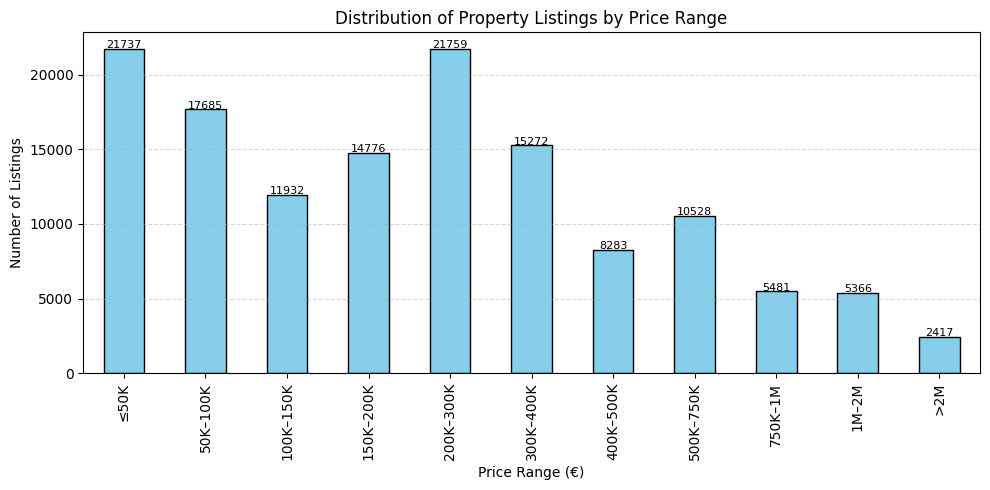

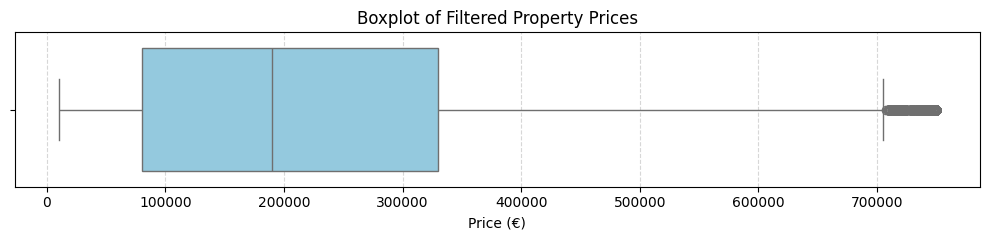

📊 Count: 119248
📊 min: 10000.0
📊 25%: 80000.0
📊 Mean: 228903.01
📉 Std Dev: 175666.95
📈 75%: 330000.0
📌 Max: 750000.0


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Definir bins e labels (não alterar o dataframe original)
price_bins = [0, 50_000, 100_000, 150_000, 200_000, 300_000, 400_000, 500_000, 750_000, 1_000_000, 2_000_000, np.inf]
labels = [
    "≤50K", "50K–100K", "100K–150K", "150K–200K", "200K–300K",
    "300K–400K", "400K–500K", "500K–750K", "750K–1M", "1M–2M", ">2M"
]

prices = pd.to_numeric(property_listings["Price"], errors="coerce")

# Criar coluna temporária com faixas
price_range_temp = pd.cut(prices, bins=price_bins, labels=labels)

# Contagem por faixa
price_range_counts = price_range_temp.value_counts().reindex(labels)

# Gráfico de barras
plt.figure(figsize=(10, 5))
ax = price_range_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Distribution of Property Listings by Price Range")
plt.xlabel("Price Range (€)")
plt.ylabel("Number of Listings")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os valores acima de cada barra
for i, v in enumerate(price_range_counts):
    plt.text(i, v + 50, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Filtrar preços plausíveis (ex: habitações realistas entre 10K e 750K)
prices = prices[
    (property_listings["Price"] >= 10_000) &
    (property_listings["Price"] <= 750_000)
].copy()

# Boxplot atualizado
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=prices, color="skyblue")
plt.title("Boxplot of Filtered Property Prices")
plt.xlabel("Price (€)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Estatísticas
print("📊 Count:", prices.count())
print("📊 min:", round(prices.min(), 2))
print("📊 25%:", round(prices.quantile(0.25), 2))
print("📊 Mean:", round(prices.mean(), 2))
print("📉 Std Dev:", round(prices.std(), 2))
print("📈 75%:", round(prices.quantile(0.75), 2))
print("📌 Max:", round(prices.max(), 2))


##### Observations
- The majority of listings fall between **€100,000 and €400,000**, with a peak in the €200K–300K range.
- The interquartile range (IQR) is between **€80,000 and €330,000**, and the average price is approximately **€229,000**.
- Listings below **€50,000** represent around **16%** of the dataset.
- Over **13,000 properties** exceed **€750,000** (~9% of entries), indicating the presence of high-end or luxury listings.
- The boxplot suggests that prices start being flagged as statistical outliers above **~€710,000**.

#### 2.2.5 Rental Prices (`rental_prices`)

- **Granularity**: Parish-level (freguesia)  
- **Relevant columns**:
  - `geocod`: used to derive `MunicipalityCode` (last 4 digits)
  - `geodsg`: name used as `Municipality`
  - `valor`: average rent → converted to float

- Ignored columns:
  - `ind_string`, `sinal_conv`, `sinal_conv_desc`

##### Sample and Distribution (rental_prices)

This shows sample rent values and their distribution across parishes. May help detect extremely low or high values, or missing units.

In [9]:
data_profiling(rental_prices)

print("Sample: rental_prices")
display(rental_prices.sample(5, random_state=14))

print("Number of unique parish names:", rental_prices["geodsg"].nunique())

print("Top 5 most common entries:")
display(rental_prices["geodsg"].value_counts().head(5))

print("Distribution of rental prices per m² (valor):")
display(rental_prices["valor"].describe())

,Column,Data Type,Contains Nulls,Null Count,% Nulls,Non-Null Count,Unique Values,Most Frequent,Frequency (%),Min,Max,Example Value
0,geocod,object,False,0,0.00,638,638,1,0.16,None,None,1D21402
1,geodsg,object,False,0,0.00,638,616,Região Autónoma da Madeira,0.47,None,None,Trancoso
2,ind_string,object,False,0,0.00,638,343,-,31.35,None,None,-
3,valor,object,True,207,32.45,431,341,5,1.16,None,None,6.38
4,sinal_conv,object,True,431,67.55,207,2,-,96.62,None,None,x
5,sinal_conv_desc,object,True,431,67.55,207,2,Dado nulo ou não aplicável,96.62,None,None,Dado nulo ou não aplicável


Sample: rental_prices


,geocod,geodsg,ind_string,valor,sinal_conv,sinal_conv_desc
198,1910115,Ovar,"5,76",5.76,NaN,NaN
117,119,Ave,"4,61",4.61,NaN,NaN
58,11D,Douro,"3,77",3.77,NaN,NaN
405,1A0110633,Olivais,"13,79",13.79,NaN,NaN
465,11A011905,Junqueira,-,NaN,-,Dado nulo ou não aplicável


Number of unique parish names: 616
Top 5 most common entries:


geodsg
Região Autónoma da Madeira    3
Região Autónoma dos Açores    3
Algarve                       2
Espinho                       2
Palmela                       2
Name: count, dtype: int64

Distribution of rental prices per m² (valor):


count      431
unique     341
top       5.08
freq         5
Name: valor, dtype: object

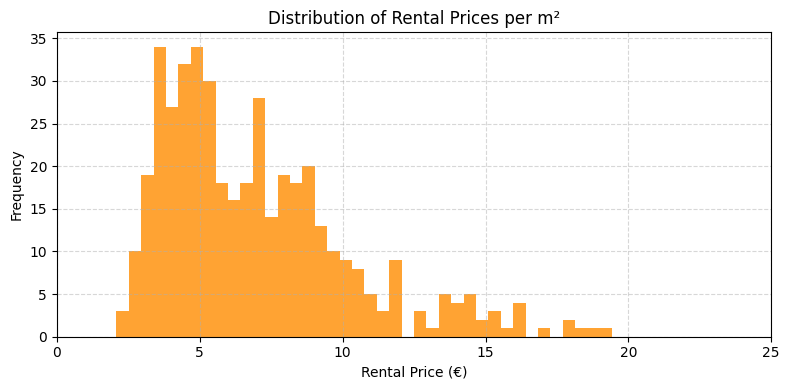

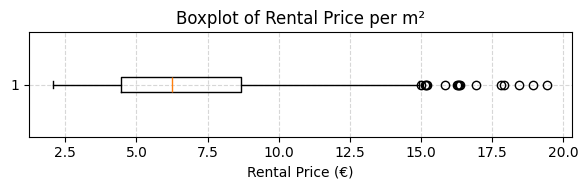

In [10]:
# Garantir tipo numérico
rental_prices["valor"] = pd.to_numeric(rental_prices["valor"], errors="coerce")

# Histograma
plt.figure(figsize=(8, 4))
plt.hist(rental_prices["valor"].dropna(), bins=40, color="darkorange", alpha=0.8)
plt.title("Distribution of Rental Prices per m²")
plt.xlabel("Rental Price (€)")
plt.ylabel("Frequency")
plt.xlim(0, 25)  # Limite visual — ajusta com base nos teus dados
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 2))
plt.boxplot(rental_prices["valor"].dropna(), vert=False)
plt.title("Boxplot of Rental Price per m²")
plt.xlabel("Rental Price (€)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### Observations
- Most rental prices per square meter fall between 4€ and 10€, with a median around 6–7€.
- The distribution is skewed to the right, indicating that a small number of parishes have significantly higher rents.
- Outliers above 15€/m² may represent urban centers or premium real estate and should be handled carefully in downstream analysis.


### 2.3 Key Identifiers Summary (REVER)

| Dataset                    | Primary Key                             | Other Relevant Columns                      |
|----------------------------|------------------------------------------|---------------------------------------------|
| `municipalities`           | `DICO` → `MunicipalityCode`             | `CONCELHO_DSG` → `Municipality`, `NUTSIII_DSG` → `Region` |
| `population_density`       | `geocod[-4:]` → `MunicipalityCode`      | `geodsg` → `Municipality`                   |
| `short_term_rental_density`| `geocod[:4]` → `MunicipalityCode`       | `geodsg` → `Municipality`                   |
| `rental_prices`            | `geocod[-4:]` → `MunicipalityCode`      | `geodsg` → `Municipality`                   |
| `property_listings`        | `City`                                   | `District`, `Price`                         |

> **Note:** The `geocod` field encodes geographic hierarchy:
> - In **parish-level** datasets (like `short_term_rental_density`), the **first 4 digits** of `geocod` identify the municipality.
> - In **municipality-level** datasets (like `population_density`), the **last 4 digits** of `geocod` represent the municipality code directly.
>
> **Example:**
> - `geocod = "150819"` in a parish-level dataset → `geocod[:4] = "1508"` (MunicipalityCode)
> - `geocod = "171508"` in a municipality-level dataset → `geocod[-4:] = "1508"` (MunicipalityCode)

This adjustment ensures all datasets can be joined consistently on the same spatial level.


### 2.4 Cleaning and Normalization Plan (REVER)

Based on the results of data profiling, the following cleaning and normalization steps will be applied:

- Convert all `valor` columns (indicators such as rental price, population density, etc.) to numeric (float) types to allow consistent analysis and aggregation.  
- Remove rows with null or invalid values in critical fields, such as `Price` in `property_listings`, to avoid errors in downstream processing.  
- Fill missing values in rental prices (`valor` in `rental_prices`) with municipality-level averages to ensure data completeness and avoid bias from missing records.  
- Normalize all location-related textual fields (e.g., municipality, district, region names) by:  
  - Removing accents and diacritics  
  - Converting text to lowercase  
  - Trimming leading and trailing whitespace  
  - Creating new normalized columns (e.g., `municipality_norm`, `district_norm`, `region_norm`) for reliable record linkage and joins.

Normalization of location names reduces mismatches caused by variations in spelling, case, or extra spaces, enabling accurate and consistent record linkage. While filtering out extreme values is necessary for data quality and reliability, it may also exclude valid outliers that could be significant for further analysis.

### 2.5 Granularity Adjustment

To prepare for schema integration, it is necessary that all datasets share the same level of spatial granularity.

- **Parish-level datasets**: `short_term_rental_density`, `rental_prices`  
- **Municipality-level datasets**: `municipalities`, `population_density`, `property_listings`

The approach to unify them includes:

- Extracting the `MunicipalityCode` key consistently from the `geocod` field:  
  - For parish-level datasets, extract the **first 4 digits** of `geocod` (e.g., `150819` → `1508`).  
  - For municipality-level datasets, extract the **last 4 digits** of `geocod` (e.g., `171508` → `1508`).  

- Aggregating parish-level data to municipality level by computing the mean per `MunicipalityCode`, to align with the granularity of municipality-level datasets.

This harmonization ensures that all datasets can be merged and analyzed together reliably.

### 2.6 Summary

Data profiling highlighted inconsistencies, missing data, and outliers across datasets, informing the cleaning and imputation strategies detailed in the following phases. These preparatory steps ensure robustness in the integration and analysis stages.


---

## 3. 🧹 Data Cleaning

In this section, we apply all the cleaning and normalization operations identified during the profiling phase.

This includes:
- Type conversion of indicator columns (`valor`)
- Removal of invalid or null entries
- Standardization of text fields (municipality, region, district)
- Extraction of `MunicipalityCode` from `geocod`
- Aggregation of parish-level data to municipality level
- Removal of unwanted columns

### 3.1 Remove Unwanted Columns

During the data cleaning phase, it is essential to remove columns that do not contribute meaningful information, contain mostly missing or irrelevant data, or are outside the project’s scope. This step helps simplify the dataset, reduce noise, and improve the efficiency of subsequent processing and analysis.

#### Removal Strategy (REVER)

- **Property Listings:**  
  Remove placeholder columns such as those starting with `Unnamed:` and the `Town` column, since the project focuses on municipality-level data, not parish-level.

- **Rental Prices and Short-Term Rental Density:**  
  Drop columns like `ind_string`, `sinal_conv`, and `sinal_conv_desc` as they are duplicates or metadata not useful for analysis.

- **Population Density:**  
  Remove `ind_string`, which duplicates information in the `valor` column.

- **Municipalities:**  
  Remove geographic or physical measurement columns such as area, perimeter, and altitude which are outside the scope of this project’s analytical objectives.

In [11]:
# Property Listings
columns_to_drop_listings = [
    'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
    'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'
]
property_listings = property_listings.drop(columns=columns_to_drop_listings, errors='ignore')

# Rental Prices
columns_to_drop_rental = ['ind_string', 'sinal_conv', 'sinal_conv_desc']
rental_prices = rental_prices.drop(columns=columns_to_drop_rental, errors='ignore')

# Population Density
columns_to_drop_pop_density = ['ind_string']
population_density = population_density.drop(columns=columns_to_drop_pop_density, errors='ignore')

# Short-Term Rental Density
columns_to_drop_str_density = ['ind_string', 'sinal_conv', 'sinal_conv_desc']
short_term_rental_density = short_term_rental_density.drop(columns=columns_to_drop_str_density, errors='ignore')

# Municipalities
columns_to_drop_municipalities = ['AREA_2019_ha', 'AREA_2019_km2', 'PERIM_km', 'ALTITUDE_MAX_m', 'ALTITUDE_MIN_m']
municipalities = municipalities.drop(columns=columns_to_drop_municipalities, errors='ignore')

# Confirm the resulting columns after dropping
print("Cleaned Property Listings Columns:", property_listings.columns.tolist())
print("Cleaned Rental Prices Columns:", rental_prices.columns.tolist())
print("Cleaned Population Density Columns:", population_density.columns.tolist())
print("Cleaned STR Density Columns:", short_term_rental_density.columns.tolist())
print("Cleaned Municipalities Columns:", municipalities.columns.tolist())


Cleaned Property Listings Columns: ['Price', 'District', 'City', 'Town']
Cleaned Rental Prices Columns: ['geocod', 'geodsg', 'valor']
Cleaned Population Density Columns: ['geocod', 'geodsg', 'valor']
Cleaned STR Density Columns: ['geocod', 'geodsg', 'valor']
Cleaned Municipalities Columns: ['DICO', 'NUTSI_DSG', 'NUTSI_COD', 'NUTSII_DSG', 'NUTSII_COD', 'NUTSIII_DSG', 'NUTSIII_COD', 'DISTRITO_ILHA_DSG', 'CONCELHO_DSG']



#### Summary of Columns Removed by Dataset

| Dataset                   | Columns Removed                                      | Reason                                         |
|---------------------------|-----------------------------------------------------|------------------------------------------------|
| `property_listings`        | `Unnamed: 4` to `Unnamed: 13`, `Town`               | Placeholders and non-municipality level data  |
| `rental_prices`            | `ind_string`, `sinal_conv`, `sinal_conv_desc`       | Duplicate or metadata columns                   |
| `population_density`       | `ind_string`                                         | Duplicate column                               |
| `short_term_rental_density`| `ind_string`, `sinal_conv`, `sinal_conv_desc`       | Duplicate or metadata columns                   |

This cleaning step prepares the datasets for the next phases of the project by focusing on essential variables for analysis and integration.

### 3.2 Type Conversion

All datasets containing the `valor` column will be converted to numeric format to ensure consistency and allow aggregations.


In [12]:
rental_prices["valor"] = pd.to_numeric(rental_prices["valor"], errors="coerce")
population_density["valor"] = pd.to_numeric(population_density["valor"], errors="coerce")
short_term_rental_density["valor"] = pd.to_numeric(short_term_rental_density["valor"], errors="coerce")
property_listings["Price"] = pd.to_numeric(property_listings["Price"], errors="coerce")

# Confirm conversion
print("Rental Prices:")
display(rental_prices["valor"].describe())

print("Population Density:")
display(population_density["valor"].describe())

print("Short-Term Rental Density:")
display(short_term_rental_density["valor"].describe())

print("Property Listings:")
display(property_listings["Price"].describe())

Rental Prices:


count    431.000000
mean       6.968910
std        3.324127
min        2.080000
25%        4.475000
50%        6.250000
75%        8.675000
max       19.440000
Name: valor, dtype: float64

Population Density:


count     347.000000
mean      295.302017
std       797.633493
min         4.200000
25%        26.300000
50%        76.100000
75%       189.350000
max      7495.900000
Name: valor, dtype: float64

Short-Term Rental Density:


count    3439.000000
mean      189.587991
std       606.158926
min         2.100000
25%        19.150000
50%        46.800000
75%       115.300000
max      9815.000000
Name: valor, dtype: float64

Property Listings:


count    1.352360e+05
mean     3.681374e+05
std      3.804044e+06
min      1.000000e+00
25%      8.400000e+04
50%      2.100000e+05
75%      3.950000e+05
max      1.380000e+09
Name: Price, dtype: float64

### 3.3 Remove Invalid Price Entries

Rows in `property_listings` with missing `Price` will be removed to ensure reliable analysis.


In [13]:
# ✅ Initial check
print(f"✅ Property listings before filtering null prices: {property_listings.shape[0]} rows")
display(property_listings.sample(5, random_state=1))

# Remove null prices
property_listings = property_listings[property_listings["Price"].notnull()]
print(f"✅ After removing null prices: {property_listings.shape[0]} rows")

# Remove listings with Price < 50,000 or > 750,000
property_listings = property_listings[(property_listings["Price"] >= 50_000) & (property_listings["Price"] <= 750_000)]
print(f"✅ After removing extreme prices (<10K or >750K): {property_listings.shape[0]} rows")
display(property_listings["Price"].describe())

✅ Property listings before filtering null prices: 135536 rows


,Price,District,City,Town
105536,99000.0,Porto,Gondomar,"Gondomar (São Cosme), Valbom e Jovim"
110762,55000.0,Setúbal,Almada,Charneca de Caparica e Sobreda
78832,75000.0,Coimbra,Coimbra,"Coimbra (Sé Nova, Santa Cruz, Almedina e São B..."
72670,595000.0,Braga,Guimarães,Silvares
116420,850000.0,Porto,Valongo,Alfena


✅ After removing null prices: 135236 rows
✅ After removing extreme prices (<10K or >750K): 101130 rows


count    101130.000000
mean     264314.605646
std      167663.876036
min       50000.000000
25%      134775.000000
50%      227500.000000
75%      359900.000000
max      750000.000000
Name: Price, dtype: float64

### 3.4 Normalize Text Columns

The following fields will be normalized:
- `Municipality`, `District`, `Region`

Normalization steps:
- Remove accents
- Convert to lowercase
- Trim whitespace
- Store results in new columns ending with `_norm`


In [14]:
!pip install unidecode


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from unidecode import unidecode

def normalize_text(text):
    if pd.isnull(text):
        return ""
    return unidecode(str(text)).lower().strip()

#### 3.4.1 Text Normalization: Municipalities Dataset

To ensure robust integration and reliable record linkage, we normalize all relevant textual columns in the `municipalities` dataset. This includes converting text to lowercase, removing diacritics, and trimming whitespace. The normalized columns will be used throughout the data integration pipeline.

In [16]:
# Normalize text in municipalities dataset
municipalities["nutsi_norm"] = municipalities["NUTSI_DSG"].apply(normalize_text)
municipalities["nutsii_norm"] = municipalities["NUTSII_DSG"].apply(normalize_text)
municipalities["nutsiii_norm"] = municipalities["NUTSIII_DSG"].apply(normalize_text)
municipalities["municipality_norm"] = municipalities["CONCELHO_DSG"].apply(normalize_text)
municipalities["region_norm"] = municipalities["NUTSIII_DSG"].apply(normalize_text)
municipalities["district_norm"] = municipalities["DISTRITO_ILHA_DSG"].apply(normalize_text)

print("Sample normalized municipality names:")
display(municipalities.drop_duplicates().sample(5, random_state=2))
print("Unique municipality names:", municipalities["municipality_norm"].nunique())

Sample normalized municipality names:


,DICO,NUTSI_DSG,NUTSI_COD,NUTSII_DSG,NUTSII_COD,NUTSIII_DSG,NUTSIII_COD,DISTRITO_ILHA_DSG,CONCELHO_DSG,nutsi_norm,nutsii_norm,nutsiii_norm,municipality_norm,region_norm,district_norm
172,1210,CONTINENTE,1,ALENTEJO,18,ALTO ALENTEJO,186,PORTALEGRE,MARVÃO,continente,alentejo,alto alentejo,marvao,alto alentejo,portalegre
273,1820,CONTINENTE,1,NORTE,11,DOURO,11D,VISEU,TAROUCA,continente,norte,douro,tarouca,douro,viseu
7,108,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ESTARREJA,continente,centro,regiao de aveiro,estarreja,regiao de aveiro,aveiro
84,615,CONTINENTE,1,CENTRO,16,REGIÃO DE COIMBRA,16E,COIMBRA,SOURE,continente,centro,regiao de coimbra,soure,regiao de coimbra,coimbra
214,1419,CONTINENTE,1,CENTRO,16,MÉDIO TEJO,16I,SANTARÉM,TORRES NOVAS,continente,centro,medio tejo,torres novas,medio tejo,santarem


Unique municipality names: 307


#### 3.4.2 Text Normalization: Property Listings

For the property listings dataset, we normalize all administrative location fields to improve consistency and allow for accurate merging with reference datasets. The following columns are normalized:

In [17]:
# Normalize property_listings
property_listings["district_norm"] = property_listings["District"].apply(normalize_text)
property_listings["municipality_norm"] = property_listings["City"].apply(normalize_text)
property_listings["parish_norm"] = property_listings["Town"].apply(normalize_text)

# Preview some normalized values
print("Sample normalized city names (listings):")
display(property_listings.drop_duplicates().sample(5, random_state=2))
print("Unique City names:", property_listings["City"].nunique())

Sample normalized city names (listings):


,Price,District,City,Town,district_norm,municipality_norm,parish_norm
118004,69900.0,Braga,Póvoa de Lanhoso,Calvos e Frades,braga,povoa de lanhoso,calvos e frades
5674,251100.0,Évora,Estremoz,Glória,evora,estremoz,gloria
46067,195000.0,Porto,Gondomar,Rio Tinto,porto,gondomar,rio tinto
60218,420000.0,Lisboa,Lisboa,Santo António,lisboa,lisboa,santo antonio
24709,165000.0,Porto,Gondomar,Rio Tinto,porto,gondomar,rio tinto


Unique City names: 273


#### 3.4.3 Text Normalization: Rental Prices

In the rental prices dataset, we normalize the `geodsg` field (parish name) for better matching and aggregation. This step is critical for aligning rental price information with administrative reference data.

In [18]:
rental_prices["parish_norm"] = rental_prices["geodsg"].apply(normalize_text)

print("Sample normalized parish names (rental prices):")
display(rental_prices.drop_duplicates().sample(5, random_state=2))
print("Unique parish names:", rental_prices["parish_norm"].nunique())

Sample normalized parish names (rental prices):


,geocod,geodsg,valor,parish_norm
586,1C20203,Alvito,NaN,alvito
391,1A0110906,Ericeira,11.76,ericeira
1,11E0410,Vila Flor,2.29,vila flor
67,11C1301,Amarante,3.88,amarante
84,1D31414,Rio Maior,4.13,rio maior


Unique parish names: 615


#### 3.4.4 Text Normalization: Population Density

For the population density dataset, the municipality name (`geodsg`) is normalized, enabling consistent joins and aggregations with other sources.

In [19]:
population_density["municipality_norm"] = population_density["geodsg"].apply(normalize_text)

print("Sample normalized municipality names (population density):")
display(population_density.drop_duplicates().sample(5, random_state=2))
print("Unique municipality names:", population_density["municipality_norm"].nunique())

Sample normalized municipality names (population density):


,geocod,geodsg,valor,municipality_norm
67,1C20201,Aljustrel,19.5,aljustrel
170,11C1804,Cinfães,72.8,cinfaes
20,1C31212,Nisa,9.9,nisa
99,2004802,Santa Cruz das Flores,29.6,santa cruz das flores
286,1500816,Vila Real de Santo António,315.3,vila real de santo antonio


Unique municipality names: 340


#### 3.4.5 Text Normalization: Short-Term Rental Density

For the short-term rental density dataset, the parish name (`geodsg`) is normalized to align records across datasets.

In [20]:
short_term_rental_density["parish_norm"] = short_term_rental_density["geodsg"].apply(normalize_text)

print("Sample normalized parish names (short-term rental density):")
display(short_term_rental_density.drop_duplicates().sample(5, random_state=2))
print("Unique parish names:", short_term_rental_density["parish_norm"].nunique())

Sample normalized parish names (short-term rental density):


,geocod,geodsg,valor,parish_norm
3418,131210,Paranhos,3832.4,paranhos
2789,011109,"União das freguesias da Mealhada, Ventosa do B...",156.2,"uniao das freguesias da mealhada, ventosa do b..."
921,080301,Aljezur,20.6,aljezur
929,1204,Campo Maior,20.8,campo maior
1061,091330,União das freguesias de Freches e Torres,23.7,uniao das freguesias de freches e torres


Unique parish names: 3071


### 3.5 Extract and Unify MunicipalityCode

To enable ongoing merging and aggregation across all datasets, we need to supply each table with a shared identifier for every municipality. It creates a common key, `MunicipalityCode`, upon which all the data sources are joinable on the municipality level regardless of their initial granularity or format.

**Extraction rules applied:**
- For **parish-level datasets**:
    - `short_term_rental_density`: first 4 digits of `geocod`
    - `rental_prices`: last 4 digits of `geocod` (INE standard)
- For **municipality-level data** (e.g., `population_density`, `municipalities`): the `MunicipalityCode` is obtained as the **last 4 digits** of the `geocod` column (or the unique identifier in the reference table).

This process of harmonization is crucial for correct integration, ensuring that all the datasets apply the same standard code in referencing municipalities.

**Validation:**  
We display a sample of each dataset after extracting the `MunicipalityCode`, confirming the transformation and checking the format of the resulting column.

> This unified code will be the main key for all future joins and aggregations. It ensures that each municipality is uniquely and consistently identified, regardless of the dataset's original format or administrative level.


In [21]:
rental_prices["MunicipalityCode"] = rental_prices["geocod"].astype(str).str[-4:]
population_density["MunicipalityCode"] = population_density["geocod"].astype(str).str[-4:]
short_term_rental_density["MunicipalityCode"] = short_term_rental_density["geocod"].astype(str).str[:4:]
municipalities["MunicipalityCode"] = municipalities["DICO"].astype(str).str.zfill(4)

# Validate structure
print("Sample MunicipalityCode from rental_prices:")
display(rental_prices.drop_duplicates().head())

print("Sample MunicipalityCode from population_density:")
display(population_density.drop_duplicates().head())

print("Sample MunicipalityCode from short_term_rental_density:")
display(short_term_rental_density.drop_duplicates().head())

print("Sample MunicipalityCode from municipalities:")
display(municipalities.head())

Sample MunicipalityCode from rental_prices:


,geocod,geodsg,valor,parish_norm,MunicipalityCode
0,11D0914,Vila Nova de Foz Côa,2.08,vila nova de foz coa,0914
1,11E0410,Vila Flor,2.29,vila flor,0410
2,1960913,Trancoso,2.41,trancoso,0913
3,1960501,Belmonte,2.61,belmonte,0501
4,11C1302,Baião,2.63,baiao,1302


Sample MunicipalityCode from population_density:


,geocod,geodsg,valor,municipality_norm,MunicipalityCode
0,1500802,Alcoutim,4.2,alcoutim,0802
1,1C20209,Mértola,4.7,mertola,0209
2,1950505,Idanha-a-Nova,6.0,idanha-a-nova,0505
3,1C31203,Avis,6.3,avis,1203
4,1C31211,Monforte,7.1,monforte,1211


Sample MunicipalityCode from short_term_rental_density:


,geocod,geodsg,valor,parish_norm,MunicipalityCode
0,070513,Torre de Coelheiros,2.1,torre de coelheiros,0705
1,070601,Cabrela,2.2,cabrela,0706
2,031003,Campo do Gerês,2.3,campo do geres,0310
3,120302,Aldeia Velha,2.4,aldeia velha,1203
4,070525,União das freguesias de Nossa Senhora da Toure...,2.5,uniao das freguesias de nossa senhora da toure...,0705


Sample MunicipalityCode from municipalities:


,DICO,NUTSI_DSG,NUTSI_COD,NUTSII_DSG,NUTSII_COD,NUTSIII_DSG,NUTSIII_COD,DISTRITO_ILHA_DSG,CONCELHO_DSG,nutsi_norm,nutsii_norm,nutsiii_norm,municipality_norm,region_norm,district_norm,MunicipalityCode
0,101,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ÁGUEDA,continente,centro,regiao de aveiro,agueda,regiao de aveiro,aveiro,0101
1,102,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ALBERGARIA-A-VELHA,continente,centro,regiao de aveiro,albergaria-a-velha,regiao de aveiro,aveiro,0102
2,103,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ANADIA,continente,centro,regiao de aveiro,anadia,regiao de aveiro,aveiro,0103
3,104,CONTINENTE,1,NORTE,11,ÁREA METROPOLITANA DO PORTO,11A,AVEIRO,AROUCA,continente,norte,area metropolitana do porto,arouca,area metropolitana do porto,aveiro,0104
4,105,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,AVEIRO,continente,centro,regiao de aveiro,aveiro,regiao de aveiro,aveiro,0105


3.6 Aggregating Parish-Level Data to Municipality Level

Both `rental_prices` and `short_term_rental_density` datasets are originally reported at the **parish level** (`freguesia`). However, for consistency across all datasets, we need to take these indicators to the **municipality level** (`concelho`).

#### Aggregation Method

- **Objective:** For every municipality (`MunicipalityCode`), compute the average value of:
- **Average rent price per square meter** (`avg_rent_m2`)
- **Density of short-term rental units** (`avg_str_density`)
- **Method:** Group all records by `MunicipalityCode` and calculate the average of the indicator values.
- **Handling Missing Data:** Following aggregation, there might still be some municipalities without average rent data (because of missing or incomplete data at parish level). To handle this:
- Missing values are filled with the **average rent for the respective district** (`district_norm`). - This guarantees that no municipality will be without an estimated average rent, providing a spatially coherent imputation.

In [22]:
# --- Aggregate rental prices and STR density to municipality level ---

# Convert values to numeric (force "-" and other invalids to NaN)
rental_prices["valor"] = pd.to_numeric(rental_prices["valor"], errors="coerce")
short_term_rental_density["valor"] = pd.to_numeric(short_term_rental_density["valor"], errors="coerce")

# Aggregate mean values by MunicipalityCode
rental_prices_avg = rental_prices.groupby("MunicipalityCode", as_index=False)["valor"].mean().rename(columns={"valor": "avg_rent_m2"})
short_term_rental_density_avg = short_term_rental_density.groupby("MunicipalityCode", as_index=False)["valor"].mean().rename(columns={"valor": "avg_str_density"})

# Check municipalities missing avg_rent_m2
missing_before = rental_prices_avg[rental_prices_avg["avg_rent_m2"].isna()]["MunicipalityCode"].tolist()
print(f"Municipalities with missing avg_rent_m2 BEFORE filling: {len(missing_before)}")
if missing_before:
    print(missing_before)

# Merge with municipalities to access district_norm for imputation
rental_prices_avg = rental_prices_avg.merge(
    municipalities[["MunicipalityCode", "district_norm", "region_norm"]],
    on="MunicipalityCode", how="left"
)

# Impute missing avg_rent_m2 with district average
district_means = rental_prices_avg.groupby("district_norm")["avg_rent_m2"].transform("mean")
rental_prices_avg["avg_rent_m2"] = rental_prices_avg["avg_rent_m2"].fillna(district_means)

# Re-check for missing after imputation
missing_after = rental_prices_avg[rental_prices_avg["avg_rent_m2"].isna()]["MunicipalityCode"].tolist()
print(f"Municipalities with missing avg_rent_m2 AFTER filling: {len(missing_after)}")
if missing_after:
    print(missing_after)

# Display samples
print("🏠 Sample: Average rent per municipality")
display(rental_prices_avg.head())

print("🏡 Sample: STR density per municipality")
display(short_term_rental_density_avg.head())


Municipalities with missing avg_rent_m2 BEFORE filling: 113
['0202', '0203', '0204', '0207', '0209', '0212', '0213', '0214', '0310', '0401', '0403', '0404', '0406', '0411', '0414', '0416', '0417', '0418', '0419', '0420', '0422', '0423', '0424', '0505', '0510', '0511', '0606', '0612', '0614', '0701', '0709', '0713', '0903', '0904', '0905', '0908', '0910', '0917', '0918', '0924', '0925', '0932', '0936', '1008', '1017', '1019', '1020', '1021', '1022', '1024', '1201', '1206', '1208', '1212', '1215', '1322', '1404', '1417', '1430', '1432', '1433', '1434', '1435', '1436', '1611', '1612', '1614', '1617', '1627', '1630', '1631', '1632', '1633', '1634', '1635', '1636', '1637', '1705', '1706', '1707', '1710', '1711', '1801', '1811', '1812', '1815', '1818', '1819', '1820', '1822', '1901', '1903', '1905', '1906', '1907', '3105', '3106', '3107', '3109', '3110', '3201', '4101', '4202', '4204', '4206', '4401', '4501', '4601', '4602', '4603', '4801', '4802', '4901']
Municipalities with missing avg_ren

,MunicipalityCode,avg_rent_m2,district_norm,region_norm
0,0101,5.09,aveiro,regiao de aveiro
1,0102,5.00,aveiro,regiao de aveiro
2,0103,4.51,aveiro,regiao de aveiro
3,0104,4.59,aveiro,area metropolitana do porto
4,0105,7.61,aveiro,regiao de aveiro


🏡 Sample: STR density per municipality


,MunicipalityCode,avg_str_density
0,0101,95.716667
1,0102,73.814286
2,0103,83.336364
3,0104,48.758824
4,0105,292.854545


### 3.7 Special Cases Handling

During data profiling and identity resolution, a few special cases were detected that require special attention to ensure data quality and correct matching.

#### 3.7.1 Handle Invalid Locations and Ambigous City Names

##### 🔍 Issues Detected:

- **Duplicate or ambiguous city names**:  
  For example:
  - `"Lagoa (Algarve)"` and `"Lagoa (São Miguel)"` refer to different municipalities but share the same base name `"Lagoa"`.
  - Without disambiguation, fuzzy matching may incorrectly assign listings to the wrong municipality.

- **Invalid or irrelevant locations**:  
  - `"Brasil"` appears as a `City` in some records but is not a Portuguese municipality.
  - `"Z - Fora de Portugal"` appears in the `District` field and should be excluded.

##### ✅ Resolution Strategy:

To handle these cases and improve identity resolution:

1. **Remove invalid locations** from the dataset:
   - Filter out listings where the `District` is `"Z - Fora de Portugal"` or the `City` is `"Brasil"`.


In [23]:
# Remove entries clearly outside the target domain
invalid_cities = ["brasil"]
invalid_districts = ["Z - Fora de Portugal"]

property_listings = property_listings[
    (~property_listings["municipality_norm"].isin(invalid_cities)) &
    (~property_listings["District"].isin(invalid_districts))
].copy()

2. **Strip parentheses for fuzzy matching only**:
   - Remove parentheses from `municipality_norm` of `listings`. 

In [24]:
import re

# Função para remover conteúdo entre parênteses
def strip_parentheses(text):
    return re.sub(r"\s*\(.*?\)", "", text).strip()

# Aplicar apenas onde existe parênteses
mask_has_parentheses = property_listings["municipality_norm"].str.contains(r"\(.*\)", regex=True, na=False)
property_listings.loc[mask_has_parentheses, "municipality_norm"] = property_listings.loc[mask_has_parentheses, "municipality_norm"].apply(strip_parentheses)


3. **Create contextual identifiers** for identity resolution:
   - Instead of comparing just normalized city names (`municipality_norm`), we use a new field:
     ```
     location_context = municipality_norm + " " + district_norm
     ```
   - This provides additional disambiguation when comparing listings to official municipality records.

In [25]:
# create location context string
property_listings["location_context"] = property_listings["municipality_norm"] + " " + property_listings["district_norm"]
municipalities["location_context"] = municipalities["municipality_norm"] + " " + municipalities["district_norm"]


> These steps ensure that each listing is assigned the correct `MunicipalityCode`, improving the quality of downstream analysis and aggregation.

### 3.7.2 Special Filling for Autonomous Regions (Madeira and Azores) (REVER)

Some municipalities in the Autonomous Regions of Madeira and Azores have missing values for the average rent per square meter (`avg_rent_m2`).  
This is usually due to the lack of source data for some or all parishes in these regions.

To ensure a consistent and complete dataset for all municipalities, we apply a stepwise imputation:

#### 1. District-Level Imputation

For most mainland municipalities, missing `avg_rent_m2` values are filled with the average rent for their respective district (`district_norm`), as performed in the previous step.

```python
# Already performed above:
district_means = rental_prices_avg.groupby("district_norm")["avg_rent_m2"].transform("mean")
rental_prices_avg["avg_rent_m2"] = rental_prices_avg["avg_rent_m2"].fillna(district_means)



#### 2. Regional Imputation for Madeira and Azores

For municipalities in Madeira and Azores where the district-level imputation still results in missing values (due to the absence of data in their entire district), we use the **regional average** as a fallback.

*   The average rent per square meter is calculated **across all municipalities** in the respective region (Madeira or Azores).
    
*   Only municipalities with missing values and belonging to "madeira" or "acores" in the region\_norm field are filled this way.

In [26]:
# Calculate region-level means
madeira_region_avg = rental_prices_avg[
    rental_prices_avg["region_norm"].str.contains("madeira", case=False, na=False)
]["avg_rent_m2"].mean()

azores_region_avg = rental_prices_avg[
    rental_prices_avg["region_norm"].str.contains("acores", case=False, na=False)
]["avg_rent_m2"].mean()

# Apply regional imputation for Madeira and Azores
def fill_missing_rent(row):
    if pd.isna(row["avg_rent_m2"]):
        if "madeira" in str(row["region_norm"]).lower():
            return madeira_region_avg
        elif "acores" in str(row["region_norm"]).lower():
            return azores_region_avg
    return row["avg_rent_m2"]

rental_prices_avg["avg_rent_m2"] = rental_prices_avg.apply(fill_missing_rent, axis=1)

##### ⚠️ Impact of the Imputation Decision

Filling missing average rent values using regional averages involves a trade-off between data completeness and local specificity:

*   **Loss of local variation:** Replacing missing values with regional averages smooths out differences that may exist within the municipalities themselves, reducing data granularity.
    
*   **Improved spatial completeness:** This imputation avoids excluding entire municipalities from the analysis, which could bias the results or reduce the study’s coverage.
    
*   **Adequacy for project scope:** Considering the objective of regional analysis and the limited data availability in autonomous regions, this approach is appropriate and maintains overall dataset coherence.
    
*   **Transparency:** It is essential to explicitly mention this decision in the study limitations and consider it when interpreting results, especially in analyses involving regional rent comparisons.
    

This compromise allows maximizing the use of available data, balancing statistical rigor and contextual knowledge.

---

### 4 Identity Resolution for Listings

Since the `property_listings` dataset lacks geographic codes (`MunicipalityCode`), we must match listings to municipalities based on the normalized municipality name (`municipality_norm`).

We use a fuzzy matching approach with three components:

1. **Blocking**: Limit comparisons to likely candidates using the first 4 characters of normalized names;
2. **Similarity Scoring**: Use 3 complementary metrics from the `RapidFuzz` library:
   - `token_sort_ratio`: handles reordering of words;
   - `token_set_ratio`: handles subsets and partial overlaps;
   - `ratio`: computes raw character-level similarity (Levenshtein);
3. **Thresholding**: Only matches the pair with the highest `Similiarity Score` to ensure reliability.
   

This step allows us to associate listings with a `MunicipalityCode`, enabling integration with other datasets.


In [27]:
# Create blocking key from normalized names
property_listings['block_key'] = property_listings['location_context'].str[:4]
municipalities['block_key'] = municipalities['location_context'].str[:4]

display(property_listings[['Price', 'City', 'District', 'municipality_norm', 'district_norm', 'location_context', 'block_key']].head(3))
display(municipalities[['DICO', 'NUTSIII_DSG', 'DISTRITO_ILHA_DSG', 'CONCELHO_DSG', 'municipality_norm', 'region_norm', 'district_norm', 'MunicipalityCode', 'location_context', 'block_key']].head(3))

,Price,City,District,municipality_norm,district_norm,location_context,block_key
1,223000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao
2,228000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao
3,250000.0,São Brás de Alportel,Faro,sao bras de alportel,faro,sao bras de alportel faro,sao


,DICO,NUTSIII_DSG,DISTRITO_ILHA_DSG,CONCELHO_DSG,municipality_norm,region_norm,district_norm,MunicipalityCode,location_context,block_key
0,101,REGIÃO DE AVEIRO,AVEIRO,ÁGUEDA,agueda,regiao de aveiro,aveiro,0101,agueda aveiro,ague
1,102,REGIÃO DE AVEIRO,AVEIRO,ALBERGARIA-A-VELHA,albergaria-a-velha,regiao de aveiro,aveiro,0102,albergaria-a-velha aveiro,albe
2,103,REGIÃO DE AVEIRO,AVEIRO,ANADIA,anadia,regiao de aveiro,aveiro,0103,anadia aveiro,anad


#### 4.1 Candidate Pair Generation

To further reduce computational cost and avoid unnecessary comparisons, we generate candidate pairs by joining both datasets (`property_listings` and `municipalities`) on the `block_key` field. The `block_key` is derived from the first 4 characters of the normalized `location_context` (which combines normalized municipality and district names).

This step ensures that only records with similar prefixes are compared in the subsequent fuzzy matching step, greatly improving efficiency.

> At this stage, we are only generating candidate pairs — the final match decision will be based on similarity scores computed in the next step.

In [28]:
# Step 2: Candidate pairs
candidates = pd.merge(
    property_listings[['City', 'municipality_norm', 'district_norm', 'location_context', 'block_key']],
    municipalities[['MunicipalityCode', 'municipality_norm', 'district_norm', 'location_context', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_municipality')
)

display(candidates.head(20))

,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality
0,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0116,sao joao da madeira,aveiro,sao joao da madeira aveiro
1,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro
2,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1815,sao joao da pesqueira,viseu,sao joao da pesqueira viseu
3,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1816,sao pedro do sul,viseu,sao pedro do sul viseu
4,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,3110,sao vicente,ilha da madeira,sao vicente ilha da madeira
5,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,4603,sao roque do pico,ilha do pico,sao roque do pico ilha do pico
6,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0116,sao joao da madeira,aveiro,sao joao da madeira aveiro
7,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro
8,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1815,sao joao da pesqueira,viseu,sao joao da pesqueira viseu
9,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,1816,sao pedro do sul,viseu,sao pedro do sul viseu


#### 4.2 Calculation of Similarity Score

For each pair generated in the final stage, we compute text similarity scores to measure the similarity of each listing to each municipality. We use a combination of three different metrics from the `RapidFuzz` library:

- **`token_sort_ratio`**: Doesn't care about word order; useful for comparing names such as "vila real" and "real vila".
- **`token_set_ratio`**: Handles subset matching and duplicate words; good for partial matching. - **`ratio`**: Character-level raw Levenshtein similarity; small typos and minor differences are indicated.

All measures of similarity are scaled to the range **0 to 1**, with 1 being a perfect similarity.

The final `similarity_score` is then the mean of the three measures and is a comprehensive assessment of the string similarity.

In [29]:
from rapidfuzz import fuzz

# Step 3: Compute similarity scores
candidates['sim_token_sort'] = candidates.apply(
    lambda row: fuzz.token_sort_ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

candidates['sim_token_set'] = candidates.apply(
    lambda row: fuzz.token_set_ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

candidates['sim_ratio'] = candidates.apply(
    lambda row: fuzz.ratio(row['location_context_listings'], row['location_context_municipality']) / 100,
    axis=1
)

In [30]:
candidates["similarity_score"] = np.mean(
    candidates[["sim_token_sort", "sim_token_set", "sim_ratio"]], axis=1
)

print(candidates.head(3))

                   City municipality_norm_listings district_norm_listings  \
0  São Brás de Alportel       sao bras de alportel                   faro   
1  São Brás de Alportel       sao bras de alportel                   faro   
2  São Brás de Alportel       sao bras de alportel                   faro   

   location_context_listings block_key MunicipalityCode  \
0  sao bras de alportel faro      sao              0116   
1  sao bras de alportel faro      sao              0812   
2  sao bras de alportel faro      sao              1815   

  municipality_norm_municipality district_norm_municipality  \
0            sao joao da madeira                     aveiro   
1           sao bras de alportel                       faro   
2          sao joao da pesqueira                      viseu   

  location_context_municipality  sim_token_sort  sim_token_set  sim_ratio  \
0    sao joao da madeira aveiro        0.470588       0.470588   0.549020   
1     sao bras de alportel faro        1.000000

#### 4.3 Filtering the Best Matches

To achieve high-confidence matching, we narrow down the candidate pairs to retain the highest `similarity_score` pair per city. `similarity_score` is the mean value of the three measurements (`sim_token_sort`, `sim_token_set`, and `sim_ratio`).

If a listing can belong to more than one municipality, we use the highest score in this case. This enables us to achieve **one-to-one mapping** between each listing and a municipality with no duplicate or ambiguous assignments allowed.

Why choose the pair with the highest similarity score?

We will assign **a distinct unique `MunicipalityCode` to each listing**, so each such listing will be in the dataset and will not get duplicated.
With the highest similarity score, we are maximizing the probability of obtaining a correct matching based on all available evidence of string similarity.
This approach also facilitates easy resolution of identity and is simple to audit and computationally straightforward.

In [31]:
matches = candidates.sort_values(by="similarity_score", ascending=False)
matches = matches.drop_duplicates(subset=["City"])

print(f"✅ Matches after applying 3-metric threshold: {matches.shape[0]}")
display(matches.head(10))

✅ Matches after applying 3-metric threshold: 272


,City,municipality_norm_listings,district_norm_listings,location_context_listings,block_key,MunicipalityCode,municipality_norm_municipality,district_norm_municipality,location_context_municipality,sim_token_sort,sim_token_set,sim_ratio,similarity_score
369989,Alijó,alijo,vila real,alijo vila real,alij,1701,alijo,vila real,alijo vila real,1.0,1.0,1.0,1.0
369988,Valpaços,valpacos,vila real,valpacos vila real,valp,1712,valpacos,vila real,valpacos vila real,1.0,1.0,1.0,1.0
1,São Brás de Alportel,sao bras de alportel,faro,sao bras de alportel faro,sao,0812,sao bras de alportel,faro,sao bras de alportel faro,1.0,1.0,1.0,1.0
369987,Palmela,palmela,setubal,palmela setubal,palm,1508,palmela,setubal,palmela setubal,1.0,1.0,1.0,1.0
369970,Montijo,montijo,setubal,montijo setubal,mont,1507,montijo,setubal,montijo setubal,1.0,1.0,1.0,1.0
369967,Almada,almada,setubal,almada setubal,alma,1503,almada,setubal,almada setubal,1.0,1.0,1.0,1.0
369964,Setúbal,setubal,setubal,setubal setubal,setu,1512,setubal,setubal,setubal setubal,1.0,1.0,1.0,1.0
369963,Arcos de Valdevez,arcos de valdevez,viana do castelo,arcos de valdevez viana do castelo,arco,1601,arcos de valdevez,viana do castelo,arcos de valdevez viana do castelo,1.0,1.0,1.0,1.0
33,Castro Marim,castro marim,faro,castro marim faro,cast,0804,castro marim,faro,castro marim faro,1.0,1.0,1.0,1.0
369953,Barreiro,barreiro,setubal,barreiro setubal,barr,1504,barreiro,setubal,barreiro setubal,1.0,1.0,1.0,1.0


#### 4.4 Assign Municipality Code to Listings

After determining the best match for each listing, we assign the corresponding `MunicipalityCode` to every property listing.  
This enables aggregation and integration of the listings data with all other datasets at the municipality level.

The merge is performed using the `location_context` string, ensuring each property is linked to the correct municipality.

In [ ]:
# Assign MunicipalityCode to each listing by merging with the matches DataFrame
property_listings_matched = property_listings.merge(
    matches[['location_context_listings', 'MunicipalityCode']],
    left_on='location_context',
    right_on='location_context_listings',
    how='left'
).drop(columns=['location_context_listings'])

# Show a sample of the updated DataFrame
print(property_listings_matched.head(3))

      Price District                  City                  Town  \
1  223000.0     Faro  São Brás de Alportel  São Brás de Alportel   
2  228000.0     Faro  São Brás de Alportel  São Brás de Alportel   
3  250000.0     Faro  São Brás de Alportel  São Brás de Alportel   

  district_norm     municipality_norm           parish_norm  \
1          faro  sao bras de alportel  sao bras de alportel   
2          faro  sao bras de alportel  sao bras de alportel   
3          faro  sao bras de alportel  sao bras de alportel   

            location_context block_key  
1  sao bras de alportel faro      sao   
2  sao bras de alportel faro      sao   
3  sao bras de alportel faro      sao   
      Price District                  City                  Town  \
0  223000.0     Faro  São Brás de Alportel  São Brás de Alportel   
1  228000.0     Faro  São Brás de Alportel  São Brás de Alportel   
2  250000.0     Faro  São Brás de Alportel  São Brás de Alportel   

  district_norm     municipality_norm

#### 4.5 Municipality Aggregation of Listings

Now that each property listing is associated with a `MunicipalityCode`, we can aggregate statistics at the municipal level.

For every municipality, we calculate:
- `avg_price`: Average price of property sold.
- `count_listings`: A count of the number of listings in that municipality.

Having calculated these aggregates, we join them with the primary key table of municipalities, and also:
- Average rent per square meter (`avg_rent_m2`) - Average short-term rental density (`avg_str_density`)
- Population density (`population_density`) The final combined dataset, `dfFinal`, combines all the pertinent indicators at the municipal level, and is utilized for all subsequent analytics and visualizations.

The resulting integrated dataset, `dfFinal`, brings together all relevant indicators at the municipality level, and is used for all downstream analytics and visualizations.

In [33]:
# Step 6: Aggregate statistics per municipality
stats_listings = property_listings_matched.groupby("MunicipalityCode").agg(
    avg_price=("Price", "mean"),
    count_listings=("Price", "count")
).reset_index()

In [34]:
# Step 1: Base cleaned reference table (from dfConcelhosTratado or municipalities reduced)
dfFinal = municipalities.copy()

# Step 2: Merge average rent per m²
dfFinal = dfFinal.merge(rental_prices_avg, on="MunicipalityCode", how="left")

# Step 3: Merge short-term rental density
dfFinal = dfFinal.merge(short_term_rental_density_avg, on="MunicipalityCode", how="left")

# Step 4: Merge population density
dfFinal = dfFinal.merge(
    population_density[["MunicipalityCode", "valor"]].rename(columns={"valor": "population_density"}),
    on="MunicipalityCode", how="left"
)

# Step 5: Merge listings stats (after ER)
dfFinal = dfFinal.merge(stats_listings, on="MunicipalityCode", how="left")

# Final preview
print("✅ Final integrated dataset:", dfFinal.shape)
display(dfFinal.head())

print(dfFinal["MunicipalityCode"] == "0709")


✅ Final integrated dataset: (308, 25)


,DICO,NUTSI_DSG,NUTSI_COD,NUTSII_DSG,NUTSII_COD,NUTSIII_DSG,NUTSIII_COD,DISTRITO_ILHA_DSG,CONCELHO_DSG,nutsi_norm,...,MunicipalityCode,location_context,block_key,avg_rent_m2,district_norm_y,region_norm_y,avg_str_density,population_density,avg_price,count_listings
0,101,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ÁGUEDA,continente,...,0101,agueda aveiro,ague,5.09,aveiro,regiao de aveiro,95.716667,140.8,175253.046322,367.0
1,102,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ALBERGARIA-A-VELHA,continente,...,0102,albergaria-a-velha aveiro,albe,5.00,aveiro,regiao de aveiro,73.814286,162.3,187757.570621,177.0
2,103,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,ANADIA,continente,...,0103,anadia aveiro,anad,4.51,aveiro,regiao de aveiro,83.336364,130.2,168769.920918,392.0
3,104,CONTINENTE,1,NORTE,11,ÁREA METROPOLITANA DO PORTO,11A,AVEIRO,AROUCA,continente,...,0104,arouca aveiro,arou,4.59,aveiro,area metropolitana do porto,48.758824,63.6,226243.750000,80.0
4,105,CONTINENTE,1,CENTRO,16,REGIÃO DE AVEIRO,16D,AVEIRO,AVEIRO,continente,...,0105,aveiro aveiro,avei,7.61,aveiro,regiao de aveiro,292.854545,435.5,316395.513069,1033.0


0      False
1      False
2      False
3      False
4      False
       ...  
303    False
304    False
305    False
306    False
307    False
Name: MunicipalityCode, Length: 308, dtype: bool


In [35]:
stats_listings.to_csv("dados/stats_listings.csv", index=False)
dfFinal.to_csv("dados/dfFinal.csv", index=False)

---

## 5. Data Warehouse and Data Marts

For this project, we constructed a centralized **data warehouse** that integrates all relevant datasets into a unified schema based on the municipality level (`MunicipalityCode`). This integrated dataset consolidates information on property listings, rental prices, population density, and short-term rental density, enabling comprehensive analysis of the housing market dynamics in Portugal.

### Data Marts Description

From the data warehouse, we derived specialized **data marts** that support specific analytical queries:

- **Property Market Mart:** Contains aggregated data on average property sale prices and counts of listings per municipality.
- **Rental Market Mart:** Includes average rental prices per square meter by municipality.
- **Demographic Mart:** Houses population density and other demographic indicators.
- **Short-Term Rentals Mart:** Provides density of short-term rental units by municipality.

These data marts enable focused analysis on:

- Relationships between housing prices and rental markets.
- Correlations between demographic density and housing supply.
- Impact assessments of short-term rentals on rental prices and housing availability.

### Limitations and Extensions

- Some municipalities lack listings data due to data unavailability, limiting the scope of certain analyses.
- Future work could extend the data warehouse with additional sources such as income levels, urban mobility, or economic indicators to enrich the analysis.
- Data marts are constructed from aggregated data, which may mask intra-municipality variations.

This structured approach facilitates modular, scalable analytics and supports answering both current and future research questions.


---

## 6. Exploratory Data Analysis (EDA)

### 6.1 Overview and Data Distribution

In this section, we analyze the distribution of the key project variables: average sale price, average rent price, population density, and short-term rental density. Understanding the spread and outliers will help guide subsequent analyses.

We will use histograms, boxplots, and descriptive statistics.

In this section, we compute correlation coefficients (Pearson and Spearman) between key variables to understand their linear and monotonic relationships.

Variables analyzed:
- Average Property Sale Price (`avg_price`)
- Average Rent Price per m² (`avg_rent_m2`)
- Population Density (`population_density`)
- Short-Term Rental Density (`avg_str_density`)

We also comment on the strength and direction of the correlations.


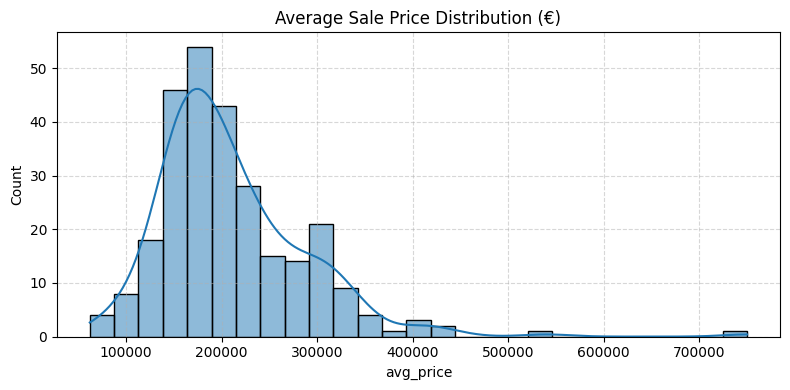

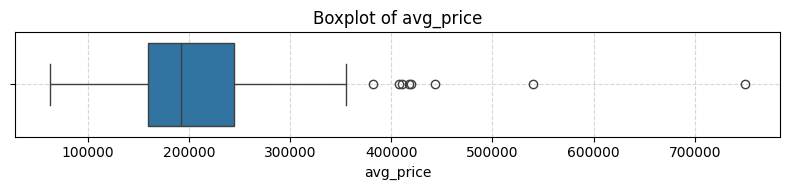

Stats for avg_price:


count       272.000000
mean     210559.579435
std       78187.338015
min       62000.000000
25%      159523.699422
50%      191650.130579
75%      244374.417045
max      750000.000000
Name: avg_price, dtype: float64

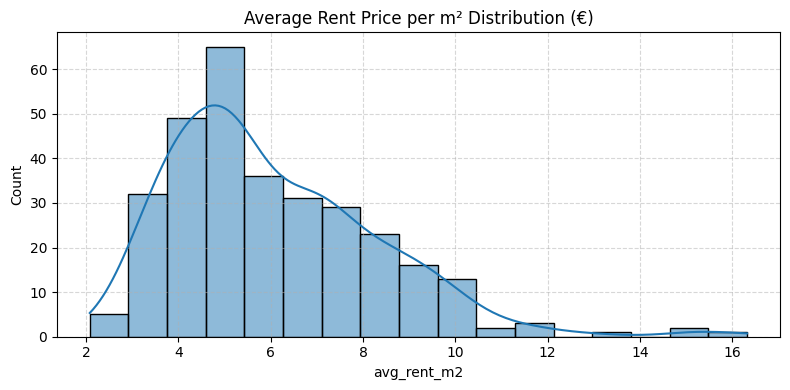

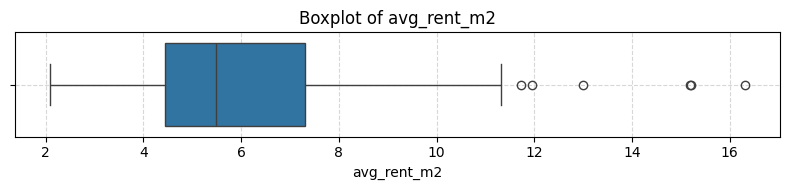

Stats for avg_rent_m2:


count    308.000000
mean       6.065110
std        2.264442
min        2.080000
25%        4.445000
50%        5.480000
75%        7.310000
max       16.320000
Name: avg_rent_m2, dtype: float64

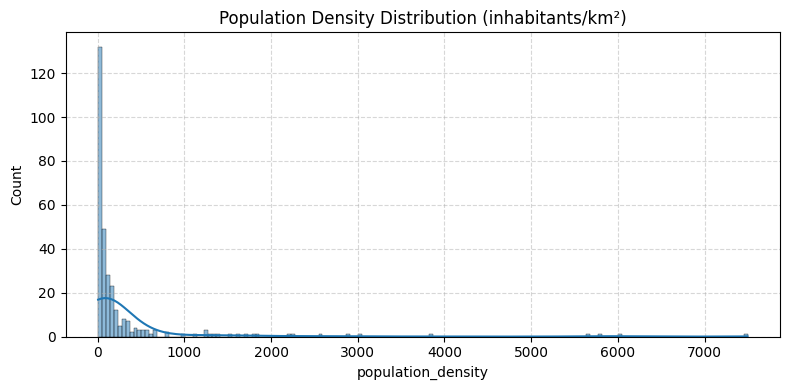

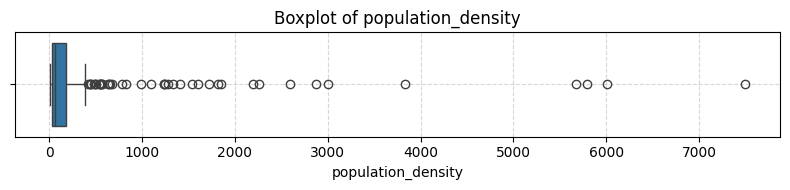

Stats for population_density:


count     308.000000
mean      303.322403
std       837.325328
min         4.200000
25%        25.400000
50%        67.300000
75%       178.900000
max      7495.900000
Name: population_density, dtype: float64

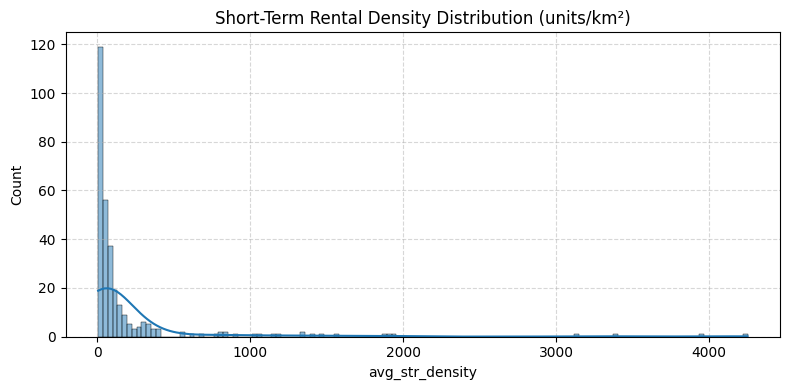

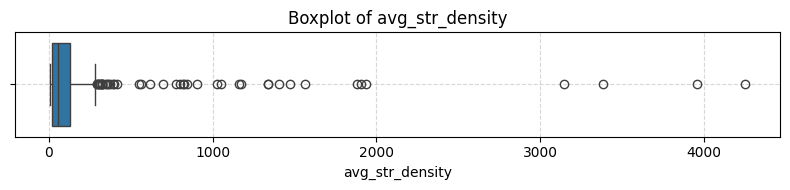

Stats for avg_str_density:


count     308.000000
mean      200.444015
std       504.546930
min         5.760000
25%        22.175323
50%        54.559659
75%       128.647941
max      4250.057143
Name: avg_str_density, dtype: float64

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["avg_price", "avg_rent_m2", "population_density", "avg_str_density"]
titles = [
    "Average Sale Price Distribution (€)",
    "Average Rent Price per m² Distribution (€)",
    "Population Density Distribution (inhabitants/km²)",
    "Short-Term Rental Density Distribution (units/km²)"
]

for var, title in zip(variables, titles):
    plt.figure(figsize=(8, 4))
    sns.histplot(dfFinal[var].dropna(), kde=True)
    plt.title(title)
    plt.xlabel(var)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 2))
    sns.boxplot(x=dfFinal[var].dropna())
    plt.title(f"Boxplot of {var}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Stats for {var}:")
    display(dfFinal[var].describe())

### 6.2 Correlation Matrix and Significance

We compute Pearson and Spearman correlation matrices to understand linear and monotonic relationships between the key variables. We also calculate p-values to check statistical significance.


In [37]:
import scipy.stats as stats
import pandas as pd

eda_df = dfFinal[variables].dropna()

pearson_corr = eda_df.corr(method="pearson")
spearman_corr = eda_df.corr(method="spearman")

print("Pearson Correlation Matrix:")
display(pearson_corr)

print("Spearman Correlation Matrix:")
display(spearman_corr)

def correlation_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvals = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            if r == c:
                pvals[r][c] = 0.0
            else:
                _, pval = stats.pearsonr(df[r], df[c])
                pvals[r][c] = round(pval, 4)
    return pvals

print("Pearson Correlation p-values:")
display(correlation_pvalues(eda_df))


Pearson Correlation Matrix:


,avg_price,avg_rent_m2,population_density,avg_str_density
avg_price,1.000000,0.322447,0.372300,0.413411
avg_rent_m2,0.322447,1.000000,0.380912,0.412704
population_density,0.372300,0.380912,1.000000,0.968046
avg_str_density,0.413411,0.412704,0.968046,1.000000


Spearman Correlation Matrix:


,avg_price,avg_rent_m2,population_density,avg_str_density
avg_price,1.000000,0.265177,0.555930,0.561023
avg_rent_m2,0.265177,1.000000,0.105665,0.147550
population_density,0.555930,0.105665,1.000000,0.958821
avg_str_density,0.561023,0.147550,0.958821,1.000000


Pearson Correlation p-values:


C:\Users\joaom\AppData\Local\Temp\ipykernel_1436\3184311768.py:21: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvals[r][c] = 0.0
C:\Users\joaom\AppData\Local\Temp\ipykernel_1436\3184311768.py:24: FutureWarning: ChainedAssignmentError: beha

,avg_price,avg_rent_m2,population_density,avg_str_density
avg_price,0.0,0.0,0.0,0.0
avg_rent_m2,0.0,0.0,0.0,0.0
avg_str_density,0.0,0.0,0.0,0.0
population_density,0.0,0.0,0.0,0.0


### 6.3 Scatterplots with Trend Lines

We visualize relationships between important variable pairs using scatterplots with regression trend lines to identify linear or nonlinear patterns.


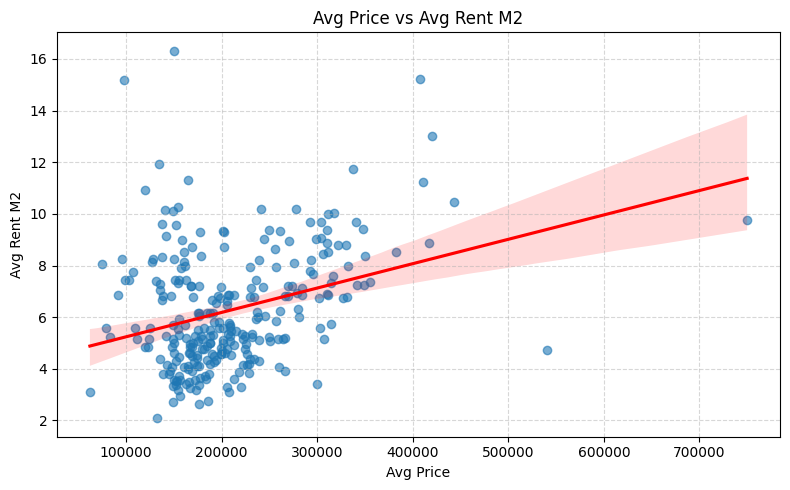

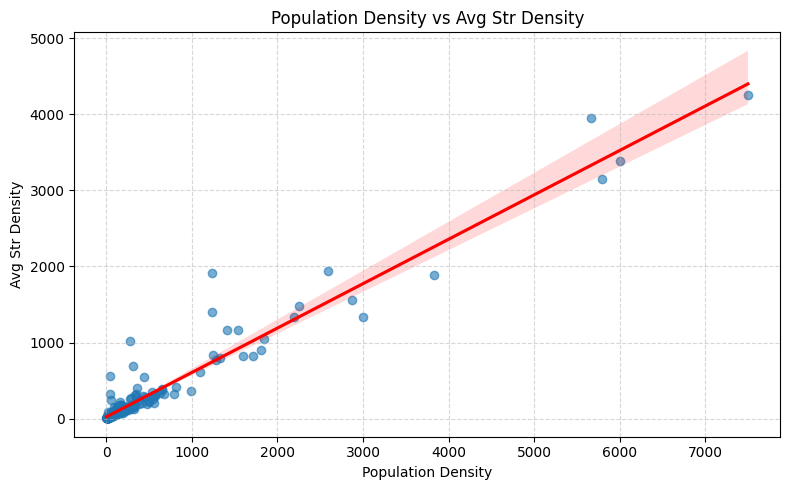

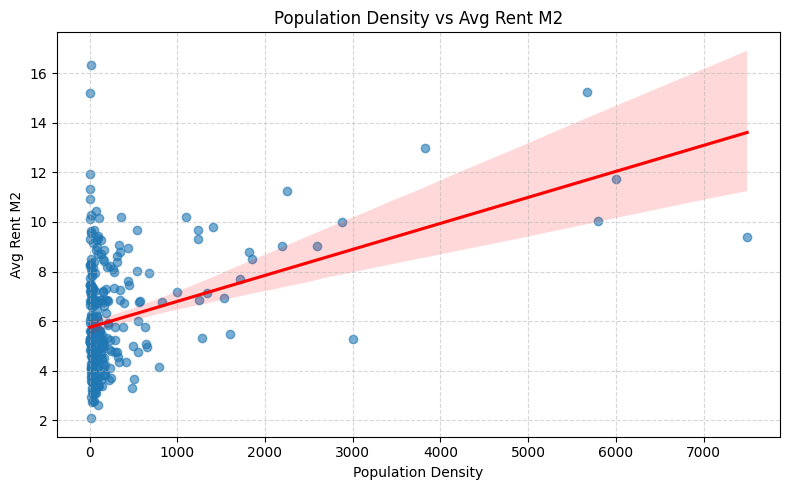

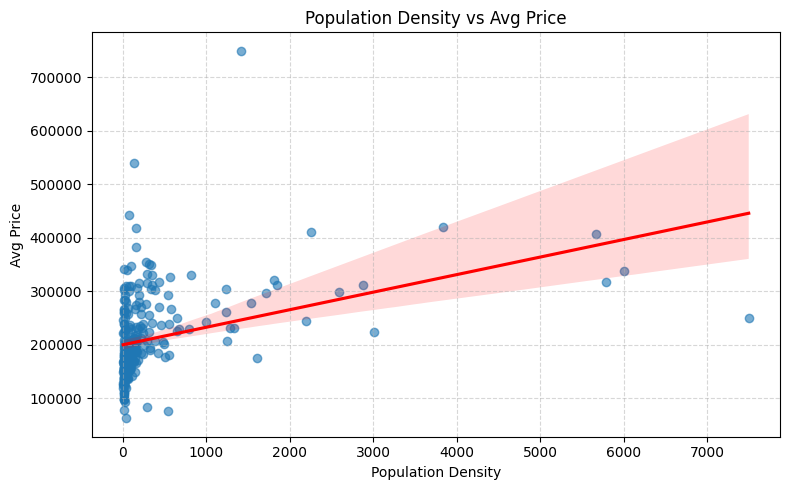

In [38]:
pairs = [
    ("avg_price", "avg_rent_m2"),
    ("population_density", "avg_str_density"),
    ("population_density", "avg_rent_m2"),
    ("population_density", "avg_price")
]

for x_var, y_var in pairs:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=dfFinal, x=x_var, y=y_var, scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
    plt.title(f"{x_var.replace('_', ' ').title()} vs {y_var.replace('_', ' ').title()}")
    plt.xlabel(x_var.replace('_', ' ').title())
    plt.ylabel(y_var.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


### 6.4 Group Comparisons (Metro vs Non-Metro)

We compare the distributions of key indicators between metropolitan municipalities (Lisbon and Porto metro areas) and non-metropolitan ones using boxplots.

First, we retrieve the municipality codes of Lisbon and Porto metro areas from our dataset to define the groups accurately.


In [39]:
lisbon_municipalities = [
    dfFinal.loc[dfFinal["region_norm_y"] == "area metropolitana de lisboa"]
]

print("Lisbon municipalities:")
for municipality in lisbon_municipalities:
    print("-", municipality)
    
porto_municipalities = [
    dfFinal.loc[dfFinal["region_norm_y"] == "area metropolitana do porto"]
]

print("Porto municipalities:")
for municipality in lisbon_municipalities:
    print("-", municipality)
    

Lisbon municipalities:
-      DICO   NUTSI_DSG  NUTSI_COD NUTSII_DSG  NUTSII_COD  \
151  1105  CONTINENTE          1     LISBOA          17   
152  1106  CONTINENTE          1     LISBOA          17   
153  1107  CONTINENTE          1     LISBOA          17   
155  1109  CONTINENTE          1     LISBOA          17   
156  1110  CONTINENTE          1     LISBOA          17   
157  1111  CONTINENTE          1     LISBOA          17   
160  1114  CONTINENTE          1     LISBOA          17   
161  1115  CONTINENTE          1     LISBOA          17   
162  1116  CONTINENTE          1     LISBOA          17   
218  1502  CONTINENTE          1     LISBOA          17   
219  1503  CONTINENTE          1     LISBOA          17   
220  1504  CONTINENTE          1     LISBOA          17   
222  1506  CONTINENTE          1     LISBOA          17   
223  1507  CONTINENTE          1     LISBOA          17   
224  1508  CONTINENTE          1     LISBOA          17   
226  1510  CONTINENTE          

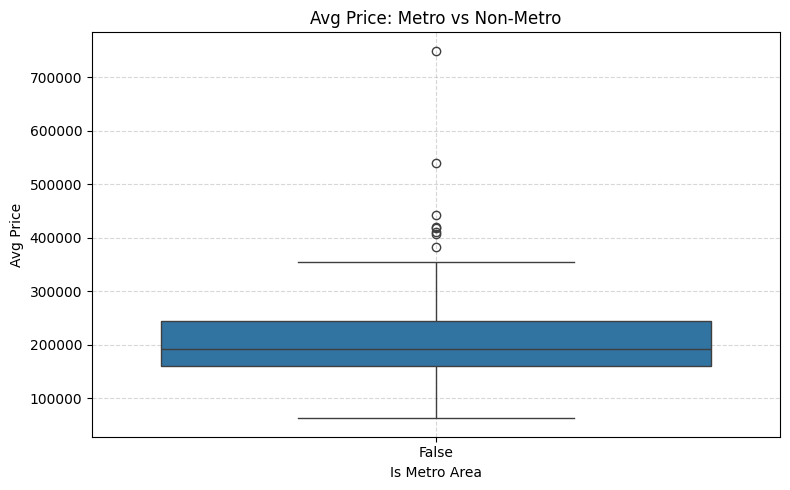

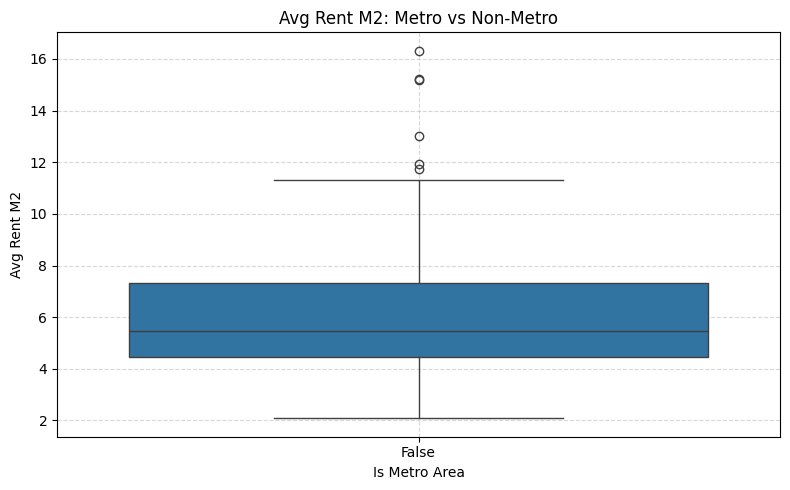

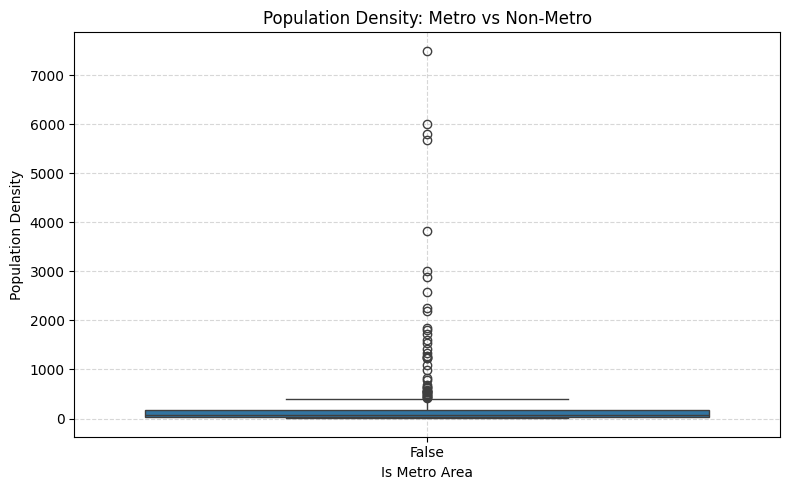

In [40]:
lisbon_metro_codes = dfFinal[dfFinal["municipality_norm"].isin(lisbon_municipalities)]["MunicipalityCode"].tolist()
porto_metro_codes = dfFinal[dfFinal["municipality_norm"].isin(porto_municipalities)]["MunicipalityCode"].tolist()

dfFinal['is_metro'] = dfFinal['MunicipalityCode'].isin(lisbon_metro_codes + porto_metro_codes)

indicators = ["avg_price", "avg_rent_m2", "population_density"]

for var in indicators:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='is_metro', y=var, data=dfFinal)
    plt.title(f"{var.replace('_', ' ').title()}: Metro vs Non-Metro")
    plt.xlabel("Is Metro Area")
    plt.ylabel(var.replace('_', ' ').title())
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## 🧱 Blocking Strategy & Similarity Metrics

Durante a resolução de identidade e planeamento da integração, é essencial preparar mecanismos que reduzam o custo computacional das comparações entre registos (blocking) e definam critérios objetivos para medir semelhança (similarity metrics).

### 📦 Blocking Strategy

**Objetivo:** Reduzir o número de comparações entre entidades de diferentes datasets, criando "blocos" onde a comparação faz sentido (ex: concelhos com o mesmo prefixo).

#### Estratégia adotada:
- Criar blocos com base no prefixo do nome normalizado (`Municipality_norm`).
- Apenas comparamos nomes dentro do mesmo bloco.

### 📏 Similarity Metrics

Após o processo de blocking, é necessário aplicar métricas de semelhança para avaliar o quão próximos são dois nomes normalizados (`Municipality_norm`) de diferentes datasets. Para isso, foram utilizadas três métricas distintas da biblioteca `RapidFuzz`, que abordam a comparação textual sob diferentes perspetivas.

#### ✅ Métricas Utilizadas

| Métrica                   | Descrição                                                                 | Vantagens                                                                 |
|---------------------------|---------------------------------------------------------------------------|---------------------------------------------------------------------------|
| `token_sort_ratio`        | Ordena alfabeticamente as palavras antes da comparação                   | Lida bem com nomes invertidos, como `"porto vila"` vs `"vila porto"`      |
| `ratio` (Levenshtein)     | Mede a distância de edição entre duas strings                            | Capta pequenas variações e erros de digitação                             |
| `token_set_ratio`         | Compara os conjuntos únicos de palavras, ignorando repetições e ordem    | Útil quando um nome é subconjunto do outro: `"santa maria da feira"` vs `"feira"` |

Estas métricas são complementares e foram escolhidas por permitirem capturar:
- semelhança estrutural (`token_sort_ratio`);
- Variações simples de escrita (`ratio`);
- Inclusões e subconjuntos de palavras (`token_set_ratio`).

> 📌 A utilização conjunta destas métricas aumenta a robustez da correspondência entre nomes, facilitando a resolução de identidade.

In [41]:
!pip install rapidfuzz


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. ✏️ Comparação 1: `listings` vs `rendas`

1.1 Carregar os datasets tratados

In [42]:
import pandas as pd
from rapidfuzz import fuzz

dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfRendas = pd.read_csv('dados/dados tradados/rendasTratado.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'dados/dados tradados/listingsTratado.csv'

> Objetivo: Importar os dois datasets que serão comparados — os listings e os valores de renda (rendas). Estes já foram limpos e normalizados anteriormente, incluindo a criação da coluna `Municipality_norm`.

1.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfRendas['block_key'] = dfRendas['Municipality_norm'].str[:4]

> Objetivo: Reduzir o número de comparações utilizando uma chave de blocking.
>- A chave `block_key` é formada pelos primeiros 4 caracteres da string normalizada (`Municipality_norm`).
>- Assim, apenas localidades com prefixos semelhantes serão comparadas, o que melhora a performance e reduz falsos positivos.

1.3 Gerar pares candidatos com base no bloco

In [ ]:
candidates = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfRendas[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_rendas')
)

> Objetivo: Criar todas as combinações possíveis dentro de cada bloco.
>- Une as duas tabelas pelos block_key.
>- O resultado é um conjunto de pares candidatos a representar a mesma entidade (concelho), mesmo que com variações no nome.

1.4 Calcular as 3 medidas de semelhança

In [ ]:
candidates['semelhança_token_sort'] = candidates.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

candidates['semelhança_levenshtein'] = candidates.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

candidates['semelhança_token_set'] = candidates.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_rendas']) / 100,
    axis=1
)

> Objetivo: Avaliar o grau de semelhança entre os nomes dos concelhos nos dois datasets usando 3 métricas:
> -    `token_sort_ratio`: ordena as palavras antes de comparar, útil quando a ordem das palavras varia.
> -    `ratio (Levenshtein)`: mede a distância de edição entre as strings.
> -    `token_set_ratio`: ignora palavras repetidas e compara subconjuntos únicos, ideal quando há muitos termos comuns.
> Valores de `0` (menos similar) a `1` (mais similar).

1.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares = candidates.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares[[
    'Municipality_listings', 'Municipality_rendas',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_rendas,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
471810,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
0,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
471790,Moita,MOITA,1.000000,1.000000,1.000000
471789,Barreiro,BARREIRO,1.000000,1.000000,1.000000
471786,Montijo,MONTIJO,1.000000,1.000000,1.000000
...,...,...,...,...,...
82394,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
88687,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
95242,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
75912,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424


> Objetivo: Ordenar os pares por semelhança mais alta (com base em `token_sort_ratio`) e apresentar os resultados mais promissores.
> - Permite analisar os pares com maior probabilidade de corresponderem à mesma entidade — essencial para fazer identity resolution entre `Municipality` do listings e `Municipality` dos valores de renda.

#### 2. ✏️ Comparação 2: `listings` vs `densidadePop`

2.1 Carregar ps datasets tratados

In [ ]:
dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfPop = pd.read_csv('dados/dados tradados/densidadePopTratado.csv')

> **Objetivo:** Importar os datasets tratados para análise — neste caso, os listings e a densidade populacional (`densidadePop`).  
> Ambos foram previamente limpos e normalizados, incluindo a coluna `Municipality_norm`.

2.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfPop['block_key'] = dfPop['Municipality_norm'].str[:4]

> **Objetivo:** Reduzir o número de comparações com base em blocos.  
> - A chave `block_key` é extraída dos primeiros 4 caracteres da `Municipality_norm`.  
> - Isso permite comparar apenas localidades com nomes semelhantes, reduzindo falsos positivos.

2.3 Gerar pares candidatos com base no bloco

In [ ]:
candidatosPop = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfPop[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_pop')
)

> **Objetivo:** Criar pares candidatos dentro de cada bloco.  
> - Junta ambos os datasets através do `block_key`.  
> - Resulta em pares com potencial para corresponder à mesma entidade.

2.4 Calcular as 3 medidas de semelhança

In [ ]:
candidatosPop['semelhança_token_sort'] = candidatosPop.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

candidatosPop['semelhança_levenshtein'] = candidatosPop.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

candidatosPop['semelhança_token_set'] = candidatosPop.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_pop']) / 100,
    axis=1
)

> **Objetivo:** Avaliar semelhança textual entre os nomes das localidades.  
> - `token_sort_ratio`: útil se a ordem das palavras varia.  
> - `ratio`: mede a distância de edição.  
> - `token_set_ratio`: ideal quando há muitos termos comuns entre os nomes.

2.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares_pop = candidatosPop.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares_pop[[
    'Municipality_listings', 'Municipality_pop',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_pop,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
494913,Valpaços,Valpaços,1.000000,1.000000,1.000000
0,Valpaços,Valpaços,1.000000,1.000000,1.000000
494894,Montalegre,Montalegre,1.000000,1.000000,1.000000
494893,Moita,Moita,1.000000,1.000000,1.000000
494892,Barreiro,Barreiro,1.000000,1.000000,1.000000
...,...,...,...,...,...
161261,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
161077,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
134729,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424
360334,Santo Tirso,Santa Cruz da Graciosa,0.242424,0.424242,0.242424


> **Objetivo:** Mostrar os pares com maior probabilidade de corresponderem à mesma entidade (`Municipality`).  
> Essencial para ligar listings à densidade populacional ao nível do concelho.

#### 3. ✏️ Comparação 2: `listings` vs `densidadeAloj`

3.1 Carregar os datasets tratados

In [ ]:
dfListings = pd.read_csv('dados/dados tradados/listingsTratado.csv')
dfAloj = pd.read_csv('dados/dados tradados/densidadeAlojTratado.csv')

> 🧾 **Objetivo:** Importar os datasets normalizados — listings e densidade de alojamentos locais.

3.2 Criar chave de blocking

In [ ]:
dfListings['block_key'] = dfListings['Municipality_norm'].str[:4]
dfAloj['block_key'] = dfAloj['Municipality_norm'].str[:4]

> **Objetivo:** Aplicar blocking para limitar as comparações a pares com prefixo semelhante.  
> Reduz o custo computacional e melhora a precisão da comparação.

3.3 Gerar pares candidatos com base no bloco

In [ ]:
candidatosAloj = pd.merge(
    dfListings[['Municipality', 'Municipality_norm', 'block_key']],
    dfAloj[['Municipality', 'Municipality_norm', 'block_key']],
    on='block_key',
    suffixes=('_listings', '_aloj')
)

> **Objetivo:** Obter pares candidatos entre listings e densidade de alojamento.  
> Os pares são agrupados com base na chave de blocking.

3.4 Calcular as 3 medidas de semelhança

In [ ]:
candidatosAloj['semelhança_token_sort'] = candidatosAloj.apply(
    lambda row: fuzz.token_sort_ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

candidatosAloj['semelhança_levenshtein'] = candidatosAloj.apply(
    lambda row: fuzz.ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

candidatosAloj['semelhança_token_set'] = candidatosAloj.apply(
    lambda row: fuzz.token_set_ratio(row['Municipality_norm_listings'], row['Municipality_norm_aloj']) / 100,
    axis=1
)

> **Objetivo:** Calcular a semelhança entre nomes para facilitar a correspondência automática.  
> As três métricas permitem complementar a análise em diferentes cenários de variação textual.

3.5 Visualizar os pares com maior semelhança

In [ ]:
top_pares_aloj = candidatosAloj.sort_values(by='semelhança_token_sort', ascending=False)

display(top_pares_aloj[[
    'Municipality_listings', 'Municipality_aloj',
    'semelhança_token_sort',
    'semelhança_levenshtein',
    'semelhança_token_set'
]])

,Municipality_listings,Municipality_aloj,semelhança_token_sort,semelhança_levenshtein,semelhança_token_set
471810,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
0,Valpaços,VALPAÇOS,1.000000,1.000000,1.000000
471790,Moita,MOITA,1.000000,1.000000,1.000000
471789,Barreiro,BARREIRO,1.000000,1.000000,1.000000
471786,Montijo,MONTIJO,1.000000,1.000000,1.000000
...,...,...,...,...,...
82394,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
88687,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
95242,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424
75912,Santo Tirso,SANTA CRUZ DA GRACIOSA,0.242424,0.424242,0.242424


> **Objetivo:** Analisar os melhores pares encontrados entre listings e densidade de alojamento local.  
> Essencial para realizar a correspondência automática entre os datasets.

### ✅ Conclusão da Resolução de Identidade

Com base na estratégia de **blocking por prefixo** e no uso de três métricas complementares de semelhança textual (`token_sort`, `token_set` e `Levenshtein`), foi possível gerar uma lista de pares candidatos com elevada probabilidade de corresponderem à mesma entidade (concelho), mesmo quando os nomes diferem ligeiramente entre datasets.

Este processo de **identity resolution** é fundamental para garantir a correta junção entre os dados dos `listings` e os restantes datasets (`rendasm2`, `densidadePopulacional`, etc.), assegurando que os valores agregados por concelho sejam coerentes e fiáveis.

As próximas etapas poderão incluir:
- Definir um **limiar de corte** para considerar pares como correspondentes (ex: ≥ 0.9 em `token_sort`);
- Realizar a **atribuição de `MunicipalityCode` ao dataset `listings`**, com base nos matches mais prováveis;
- Integrar os datasets agora harmonizados para análise estatística e visualização dos impactos territoriais.

Este processo completa a **Fase 1** do projeto, deixando os dados prontos para análise cruzada, correlações e visualizações interativas.


---

## 🧾 Conclusões e Trabalho Futuro

### ✅ Conclusões

- Os dados foram transformados e normalizados de forma a garantir **consistência semântica e estrutural** entre fontes com granularidade e formato distintos;
- Foi adotado um **modelo de integração baseado no concelho (`MunicipalityCode`)**, com o apoio de chaves auxiliares (`Municipality_norm`) para facilitar junções;
- Técnicas de **blocking e similarity metrics** permitiram gerar pares candidatos para a resolução de identidade, essencial para ligar dados do `portugal_listings` (sem `geocod`) aos restantes datasets georreferenciados;
- As três métricas escolhidas (Levenshtein, token_sort, token_set) mostraram-se eficazes na identificação de correspondências.

### 🔮 Trabalho Futuro

- **Definir limiares de confiança** para aceitar ou rejeitar pares com base nas medidas de semelhança (ex: ≥ 0.90);
- **Atribuir `MunicipalityCode` ao dataset `listings`** com base nos matches validados;
- **Integrar os datasets finais** para construir uma tabela única por concelho com: média de preços, densidade populacional, densidade de alojamentos e valor médio de renda;
- Aplicar **visualizações interativas** (ex: choropleths) para explorar o impacto do alojamento local;
- Avaliar possíveis **correlações** entre as variáveis — por exemplo, se maior densidade de listings está associada a aumento de preços ou densidade populacional.

---

> Esta preparação abre caminho para análises exploratórias, estatísticas e preditivas que respondam à questão central:  
**Qual o impacto da proliferação de Alojamentos Locais no custo e estrutura urbana do mercado de habitação em Portugal?**
